In [23]:
import pandas as pd
import os, re, sys
import numpy as np

## List-to-method correspondences

In [10]:
def get_method_dict(file):
    method_dict = {'average' : 'average'}
    with open(file, 'r') as f:
        lines = [line.rstrip() for line in f.readlines()]
        i = 1
        for l in lines:
            match = re.search(r'^.+attrib=([^_]+)_mpd.+_thresh=([^_]+)_.+$', l)
            method = match.group(1)
            threshold = match.group(2)
            key = 'list' + str(i)
            method_dict[key] = method + '_' + threshold
            i += 1
    return method_dict


In [9]:
bcms_setimes_methods = get_method_dict('shibboleth/randomized_lists.bcms_setimes.txt')
bcms_twitter_methods = get_method_dict('shibboleth/randomized_lists.bcms_twitter.txt')
estonian_voro_methods = get_method_dict('shibboleth/randomized_lists.estonian_voro.txt')
finnish_suomi24_methods = get_method_dict('shibboleth/randomized_lists.finnish.txt')
german_jodel_methods = get_method_dict('shibboleth/randomized_lists.jodel.txt')
greek_dialects_methods = get_method_dict('shibboleth/randomized_lists.greek.txt')
scandinavian_slide_methods = get_method_dict('shibboleth/randomized_lists.scandinavian.txt')

In [4]:
bcms_setimes_methods_df = pd.DataFrame.from_dict(bcms_setimes_methods, orient='index', columns=['method'])
bcms_setimes_methods_df

,method
average,average
list1,loo_0.6
list2,loo_0.1
list3,shap_0.6
list4,shap_0.1
list5,ig_0.1
list6,lime_0.6
list7,lime_0.1
list8,ig_0.6


In [5]:
bcms_twitter_methods_df = pd.DataFrame.from_dict(bcms_twitter_methods, orient='index', columns=['method'])
bcms_twitter_methods_df

,method
average,average
list1,lime_0.6
list2,loo_0.1
list3,shap_0.1
list4,ig_0.6
list5,loo_0.6
list6,ig_0.1
list7,shap_0.6
list8,lime_0.1


In [29]:
estonian_voro_methods_df = pd.DataFrame.from_dict(estonian_voro_methods, orient='index', columns=['method'])
estonian_voro_methods_df

,method
average,average
list1,ig_0.6
list2,ig_0.1
list3,loo_0.1
list4,shap_0.6
list5,shap_0.1
list6,loo_0.6
list7,lime_0.6
list8,lime_0.1


In [6]:
finnish_suomi24_methods_df = pd.DataFrame.from_dict(finnish_suomi24_methods, orient='index', columns=['method'])
finnish_suomi24_methods_df

,method
average,average
list1,shap_0.6
list2,loo_0.6
list3,ig_0.6
list4,loo_0.1
list5,lime_0.6
list6,lime_0.1
list7,ig_0.1
list8,shap_0.1


In [7]:
greek_dialects_methods_df = pd.DataFrame.from_dict(greek_dialects_methods, orient='index', columns=['method'])
greek_dialects_methods_df

,method
average,average
list1,ig_0.6
list2,shap_0.1
list3,loo_0.1
list4,loo_0.6
list5,shap_0.6
list6,ig_0.1
list7,lime_0.6
list8,lime_0.1


In [8]:
german_jodel_methods_df = pd.DataFrame.from_dict(german_jodel_methods, orient='index', columns=['method'])
german_jodel_methods_df

,method
average,average
list1,ig_0.1
list2,ig_0.6
list3,lime_0.1
list4,lime_0.6
list5,shap_0.6
list6,shap_0.1
list7,loo_0.1
list8,loo_0.6


In [9]:
scandinavian_slide_methods_df = pd.DataFrame.from_dict(scandinavian_slide_methods, orient='index', columns=['method'])
scandinavian_slide_methods_df

,method
average,average
list1,lime_0.1
list2,ig_0.1
list3,shap_0.1
list4,shap_0.6
list5,loo_0.1
list6,loo_0.6
list7,ig_0.6
list8,lime_0.6


## Importing all lists and labelling them with list ID

In [12]:
def make_dataset_df(folder):
    dfs = list()
    files = os.listdir(folder)
    for file in files:
        print(file)
        if file.endswith('.csv'):
            id = re.sub('.csv', '', file)
            df = pd.read_csv(folder + '/' + file)
            df['file'] = id
            dfs.append(df)
    full_df = pd.concat(dfs, ignore_index=True)
    return full_df

In [13]:
def get_number_annots(df):
    number_annots = df.value_counts('file').to_frame()
    number_annots = number_annots.rename(columns={number_annots.columns[0]: "total"})
    return number_annots

In [12]:
bcms_twitter_df = make_dataset_df('bcms_twitter')
bcms_twitter_df

list1.csv
list4.csv
list2.csv
list7.csv
list3.csv
list5.csv
list6.csv
list8.csv


,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,file
0,čarobna,bs,0.706716,0.875000,NaN,no,unm,NaN,NaN,list1
1,čarolije,bs,0.658181,0.656250,NaN,no,unm,NaN,NaN,list1
2,čarolija,bs,0.643859,0.968750,NaN,no,unm,NaN,NaN,list1
3,fancyasfuck,bs,0.621885,0.739583,NaN,no,foreign,NaN,NaN,list1
4,allah,bs,0.591824,0.791667,NaN,yes,lex,spel,NaN,list1
...,...,...,...,...,...,...,...,...,...,...
3195,neizvesno,sr,0.611152,0.114583,NaN,yes,phon,NaN,NaN,list8
3196,osetiti,sr,0.610422,0.187500,NaN,yes,phon,NaN,NaN,list8
3197,pobedama,sr,0.608175,0.104167,NaN,yes,phon,NaN,NaN,list8
3198,miholjskoleto,sr,0.608170,0.104167,NaN,yes,phon,nonminimal,NaN,list8


In [13]:
bcms_setimes_df = make_dataset_df('bcms_setimes')
bcms_setimes_df

list1.csv
list4.csv
list2.csv
list7.csv
list3.csv
list5.csv
list6.csv
list8.csv


,token,label,score,selection_freq,in_blacklist,shibboleth,feature,feature2,note,file
0,liječniku,hr,0.340325,0.60,True,yes,lex,NaN,jek,list1
1,slijedili,hr,0.232197,0.64,True,no,phon,NaN,jek,list1
2,razvitkom,hr,0.212817,0.75,True,yes,morph-d,NaN,NaN,list1
3,natjecateljskom,hr,0.194636,0.63,True,yes,lex,NaN,NaN,list1
4,sarachini,hr,0.190969,0.63,False,no,named entity,NaN,NaN,list1
...,...,...,...,...,...,...,...,...,...,...
1595,predsedavati,sr,0.362739,0.65,False,yes,phon,NaN,NaN,list8
1596,saopštavajući,sr,0.362684,0.92,False,yes,phon,NaN,NaN,list8
1597,evroatlantske,sr,0.362167,1.00,False,yes,phon,nonminimal,NaN,list8
1598,ignorisati,sr,0.361948,0.62,False,yes,morph-d,NaN,NaN,list8


In [30]:
estonian_voro_df = make_dataset_df('eesti-voro')
estonian_voro_df

list1.csv
.ipynb_checkpoints
list4.csv
list2.csv
list7.csv
list3.csv
list5.csv
list6.csv
list8.csv


,token,base form,cognate,label,Phon-Morph-infl-Morph-der-Spelling,Lexicon,NE,Other,Unmarked,Unknown,Comment,Comment2,file
0,tõuseb,tõusma,!= nõsõma,est,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
1,vaatame,vaatama,!= kaema,est,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
2,käisid,käima,käümä,est,xx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list1
3,võiksid,võima,võima,est,x,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list1
4,veab,vedama,vidämä,est,xx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,oppuslinõ,oppuslinõ,õpetlik,vro,x,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list8
1596,põhamaa,Põḣamaaq,Põhjamaad,vro,x,NaN,x,NaN,NaN,NaN,NaN,NaN,list8
1597,kooltõnõma,koolõnõma ?,!= hinge vaakuma,vro,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list8
1598,häügaq,häbü,häbi,vro,xx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list8


In [14]:
german_jodel_df = make_dataset_df('german_jodel')
german_jodel_df

list1.csv
.ipynb_checkpoints
list4.csv
list2.csv
list7.csv
list3.csv
list5.csv
list6.csv
list8.csv


,token,label,score,selection_freq,code,other_variety,note,file
0,körndln,AT,0.976010,0.10,morph,NaN,not exclusive,list1
1,gfahrn?“,AT,0.942268,0.10,phon,NaN,not exclusive,list1
2,wien❤️,AT,0.930604,0.10,NE,NaN,NaN,list1
3,krems/stein/mautern,AT,0.917586,0.10,NE,NaN,NaN,list1
4,datinggschichtln,AT,0.892725,0.10,morph,NaN,NaN,list1
...,...,...,...,...,...,...,...,...
3195,heinerfest,DE_S,0.313043,0.87,NE,NaN,NaN,list8
3196,ilmenau,DE_S,0.312112,1.00,NE,NaN,NaN,list8
3197,heimkommen,DE_S,0.312046,0.74,unmarked,NaN,NaN,list8
3198,passau,DE_S,0.312020,0.97,NE,NaN,NaN,list8


In [15]:
german_jodel_df['other_variety'].value_counts()

yes    10
Yes     3
Name: other_variety, dtype: int64

In [16]:
greek_dialects_df = make_dataset_df('greek_dialects')
greek_dialects_df

list1.csv
.ipynb_checkpoints
list4.csv
list2.csv
list7.csv
OLD
list3.csv
test.txt
list5.csv
list6.csv
list8.csv
Corcodial.xlsx


,token,label,score,selection_freq,feature,file
0,γλεντίζει,CRE,0.768405,0.66,Morph,list1
1,κανελλατου.γρ,CRE,0.753272,0.97,NE,list1
2,μαργαριτάρι,CRE,0.645182,0.73,Unmarked,list1
3,εκράτει,CRE,0.643721,1.00,Morph,list1
4,κλουθήξει,CRE,0.618015,0.63,Morph,list1
...,...,...,...,...,...,...
3195,φρουροί,PON,0.373081,0.24,Unmarked,list8
3196,καρενέσε,PON,0.370964,0.10,Unmarked,list8
3197,μεξικού,PON,0.369579,0.96,NE,list8
3198,χλωρίζνε,PON,0.366267,0.10,Morph,list8


In [17]:
finnish_suomi24_df = make_dataset_df('finnish_suomi24')
finnish_suomi24_df

list1.csv
list4.csv
list2.csv
list7.csv
list3.csv
list5.csv
list6.csv
list8.csv


,Unnamed: 0,token,label,score,selection_freq,category,lex_other_not,file
0,0,ollunna,east,0.379162,0.818182,morph,other,list1
1,1,hää,east,0.366869,0.989899,lex,lex,list1
2,2,aeka,east,0.361476,0.676768,phon,other,list1
3,3,minnuu,east,0.349316,0.828283,phon,other,list1
4,4,vaen,east,0.336384,0.848485,phon,other,list1
...,...,...,...,...,...,...,...,...
2015,295,mukulat,west,0.175638,0.101010,not,not,list8
2016,296,kauhavalaanen,west,0.175430,0.101010,phon,other,list8
2017,297,pikkase.kerros,west,0.174050,0.101010,not,not,list8
2018,298,vitsikäs,west,0.173803,0.101010,not,not,list8


In [18]:
scandinavian_slide_df = make_dataset_df('scandinavian_slide')
scandinavian_slide_df

list1.csv
list4.csv
list2.csv
list7.csv
list3.csv
list5.csv
list6.csv
list8.csv


,id,token,label,score,selection_freq,in_blacklist,cognate_da,cognate_nb,cognate_nn,cognate_sv,NotShib,NotMinimal,Morph,Phon_Spell,NE,Typo_Unk,LexShib,Counterex,NonLexShib,file
0,0,uddannelsesinstitutionerne,da,0.996353,0.10,False,NaN,utdannelsesinstitusjonene,NaN,NaN,False,True,True,True,False,False,False,False,True,list1
1,1,influenza,da,0.993078,0.10,False,NaN,influensa,influensa,influensa,False,False,False,True,True,False,False,False,True,list1
2,2,forsigtigere,da,0.992772,0.10,False,NaN,forsiktigere,forsiktigare,försiktigare,False,False,False,True,False,False,False,False,True,list1
3,3,standardindstillingerne,da,0.992396,0.10,False,NaN,standardinnstillingene,standardinnstilling?,standardinställning?/lemma,False,True,True,False,False,False,False,False,True,list1
4,4,historiebøger,da,0.987946,0.10,False,NaN,bøker,NaN,böcker,False,True,False,True,False,False,False,False,True,list1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,395,lämnade,sv,0.155722,0.98,False,efterlod,etterlot,NaN,NaN,False,False,False,False,False,False,True,False,False,list8
3196,396,färdiga,sv,0.154972,0.75,False,NaN,ferdige,ferdige,NaN,False,False,False,True,False,False,False,False,True,list8
3197,397,väntar,sv,0.154830,1.00,False,venter,venter,ventar,NaN,False,False,True,True,False,False,False,False,True,list8
3198,398,förändras,sv,0.154672,0.77,False,NaN,forandre,forandre,NaN,False,False,True,True,False,False,False,False,True,list8


# Data preparation

Aim: data frame containing the percentage of lexical shibboleths, other shibboleths, non shibboleths and if applicable other annotations

## Preparing bcms_setimes dataframe

In [19]:
number_annots = get_number_annots(bcms_setimes_df)
number_annots

,total
file,
list1,200
list2,200
list3,200
list4,200
list5,200
list6,200
list7,200
list8,200


In [20]:
bcms_setimes_shib_distro = bcms_setimes_df[(bcms_setimes_df['shibboleth'] == 'yes') & (bcms_setimes_df['feature'] == 'lex')].groupby('file').size().to_frame(name='lex shib')
bcms_setimes_shib_distro['nonlex shib'] = bcms_setimes_df[(bcms_setimes_df['shibboleth'] == 'yes') & (bcms_setimes_df['feature'] != 'lex')].groupby('file').size()
bcms_setimes_shib_distro['non shib'] = bcms_setimes_df[bcms_setimes_df['shibboleth'] == 'no'].groupby('file').size()
bcms_setimes_shib_distro['rest'] = bcms_setimes_df[(bcms_setimes_df['shibboleth'] != 'no') & (bcms_setimes_df['shibboleth'] != 'yes')].groupby('file').size()
bcms_setimes_shib_distro = pd.concat([bcms_setimes_shib_distro, number_annots], axis=1)
bcms_setimes_shib_distro['shibboleths: lexical'] = round(bcms_setimes_shib_distro['lex shib'] / bcms_setimes_shib_distro['total'] * 100, 1)
bcms_setimes_shib_distro['shibboleths: other'] = round(bcms_setimes_shib_distro['nonlex shib'] / bcms_setimes_shib_distro['total'] * 100, 1)
bcms_setimes_shib_distro['non shibboleths'] = round(bcms_setimes_shib_distro['non shib'] / bcms_setimes_shib_distro['total'] * 100, 1)
bcms_setimes_shib_distro['other'] = round(bcms_setimes_shib_distro['rest'] / bcms_setimes_shib_distro['total'] * 100, 1)
bcms_setimes_shib_distro['perc sum'] = bcms_setimes_shib_distro['shibboleths: lexical'] + bcms_setimes_shib_distro['shibboleths: other'] \
+ bcms_setimes_shib_distro['non shibboleths'] + bcms_setimes_shib_distro['other']
bcms_setimes_shib_distro.loc['average'] = round(bcms_setimes_shib_distro.mean(axis=0), 1)
bcms_setimes_shib_distro

,lex shib,nonlex shib,non shib,rest,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc sum
file,,,,,,,,,,
list1,33.0,70.0,94.0,3.0,200.0,16.5,35.0,47.0,1.5,100.0
list2,14.0,49.0,131.0,6.0,200.0,7.0,24.5,65.5,3.0,100.0
list3,33.0,72.0,95.0,NaN,200.0,16.5,36.0,47.5,NaN,NaN
list4,15.0,45.0,135.0,5.0,200.0,7.5,22.5,67.5,2.5,100.0
list5,20.0,58.0,120.0,2.0,200.0,10.0,29.0,60.0,1.0,100.0
list6,37.0,85.0,75.0,3.0,200.0,18.5,42.5,37.5,1.5,100.0
list7,22.0,88.0,82.0,8.0,200.0,11.0,44.0,41.0,4.0,100.0
list8,37.0,96.0,67.0,NaN,200.0,18.5,48.0,33.5,NaN,NaN
average,26.4,70.4,99.9,4.5,200.0,13.2,35.2,49.9,2.2,100.0


In [21]:
bcms_setimes_shib_distro = pd.concat([bcms_setimes_shib_distro, bcms_setimes_methods_df], axis=1)


In [22]:
bcms_setimes_shib_distro

,lex shib,nonlex shib,non shib,rest,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc sum,method
list1,33.0,70.0,94.0,3.0,200.0,16.5,35.0,47.0,1.5,100.0,loo_0.6
list2,14.0,49.0,131.0,6.0,200.0,7.0,24.5,65.5,3.0,100.0,loo_0.1
list3,33.0,72.0,95.0,NaN,200.0,16.5,36.0,47.5,NaN,NaN,shap_0.6
list4,15.0,45.0,135.0,5.0,200.0,7.5,22.5,67.5,2.5,100.0,shap_0.1
list5,20.0,58.0,120.0,2.0,200.0,10.0,29.0,60.0,1.0,100.0,ig_0.1
list6,37.0,85.0,75.0,3.0,200.0,18.5,42.5,37.5,1.5,100.0,lime_0.6
list7,22.0,88.0,82.0,8.0,200.0,11.0,44.0,41.0,4.0,100.0,lime_0.1
list8,37.0,96.0,67.0,NaN,200.0,18.5,48.0,33.5,NaN,NaN,ig_0.6
average,26.4,70.4,99.9,4.5,200.0,13.2,35.2,49.9,2.2,100.0,average


In [23]:
bcms_setimes_shib_distro = bcms_setimes_shib_distro.sort_values(by=['method']).reset_index(names=['list']).set_index('method')
bcms_setimes_shib_distro

,list,lex shib,nonlex shib,non shib,rest,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc sum
method,,,,,,,,,,,
average,average,26.4,70.4,99.9,4.5,200.0,13.2,35.2,49.9,2.2,100.0
ig_0.1,list5,20.0,58.0,120.0,2.0,200.0,10.0,29.0,60.0,1.0,100.0
ig_0.6,list8,37.0,96.0,67.0,NaN,200.0,18.5,48.0,33.5,NaN,NaN
lime_0.1,list7,22.0,88.0,82.0,8.0,200.0,11.0,44.0,41.0,4.0,100.0
lime_0.6,list6,37.0,85.0,75.0,3.0,200.0,18.5,42.5,37.5,1.5,100.0
loo_0.1,list2,14.0,49.0,131.0,6.0,200.0,7.0,24.5,65.5,3.0,100.0
loo_0.6,list1,33.0,70.0,94.0,3.0,200.0,16.5,35.0,47.0,1.5,100.0
shap_0.1,list4,15.0,45.0,135.0,5.0,200.0,7.5,22.5,67.5,2.5,100.0
shap_0.6,list3,33.0,72.0,95.0,NaN,200.0,16.5,36.0,47.5,NaN,NaN


In [24]:
bcms_setimes_overview = bcms_setimes_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']]
bcms_setimes_overview

,shibboleths: lexical,shibboleths: other,non shibboleths,other
method,,,,
average,13.2,35.2,49.9,2.2
ig_0.1,10.0,29.0,60.0,1.0
ig_0.6,18.5,48.0,33.5,NaN
lime_0.1,11.0,44.0,41.0,4.0
lime_0.6,18.5,42.5,37.5,1.5
loo_0.1,7.0,24.5,65.5,3.0
loo_0.6,16.5,35.0,47.0,1.5
shap_0.1,7.5,22.5,67.5,2.5
shap_0.6,16.5,36.0,47.5,NaN


## Preparing bcms_twitter dataset

In [25]:
number_annots = get_number_annots(bcms_twitter_df)
number_annots

,total
file,
list1,400
list2,400
list3,400
list4,400
list5,400
list6,400
list7,400
list8,400


In [26]:
bcms_twitter_shib_distro = bcms_twitter_df[(bcms_twitter_df['shibboleth'] == 'yes') & (bcms_twitter_df['feature'] == 'lex')].groupby('file').size().to_frame(name='lex shib')
bcms_twitter_shib_distro['nonlex shib'] = bcms_twitter_df[(bcms_twitter_df['shibboleth'] == 'yes') & (bcms_twitter_df['feature'] != 'lex')].groupby('file').size()
bcms_twitter_shib_distro['non shib'] = bcms_twitter_df[bcms_twitter_df['shibboleth'] == 'no'].groupby('file').size()
bcms_twitter_shib_distro['rest'] = bcms_twitter_df[(bcms_twitter_df['shibboleth'] != 'no') & (bcms_twitter_df['shibboleth'] != 'yes')].groupby('file').size()
bcms_twitter_shib_distro = pd.concat([bcms_twitter_shib_distro, number_annots], axis=1)
bcms_twitter_shib_distro['shibboleths: lexical'] = round(bcms_twitter_shib_distro['lex shib'] / bcms_twitter_shib_distro['total'] * 100, 1)
bcms_twitter_shib_distro['shibboleths: other'] = round(bcms_twitter_shib_distro['nonlex shib'] / bcms_twitter_shib_distro['total'] * 100, 1)
bcms_twitter_shib_distro['non shibboleths'] = round(bcms_twitter_shib_distro['non shib'] / bcms_twitter_shib_distro['total'] * 100, 1)
bcms_twitter_shib_distro['other'] = round(bcms_twitter_shib_distro['rest'] / bcms_twitter_shib_distro['total'] * 100, 1)
bcms_twitter_shib_distro['perc sum'] = bcms_twitter_shib_distro['shibboleths: lexical'] + bcms_twitter_shib_distro['shibboleths: other'] \
+ bcms_twitter_shib_distro['non shibboleths'] + bcms_twitter_shib_distro['other']
bcms_twitter_shib_distro.loc['average'] = round(bcms_twitter_shib_distro.mean(axis=0), 1)
bcms_twitter_shib_distro

,lex shib,nonlex shib,non shib,rest,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc sum
file,,,,,,,,,,
list1,15.0,109.0,268.0,8.0,400.0,3.8,27.3,67.0,2.0,100.1
list2,13.0,78.0,302.0,7.0,400.0,3.2,19.5,75.5,1.8,100.0
list3,19.0,100.0,273.0,8.0,400.0,4.8,25.0,68.2,2.0,100.0
list4,9.0,108.0,269.0,14.0,400.0,2.2,27.0,67.2,3.5,99.9
list5,9.0,97.0,284.0,10.0,400.0,2.2,24.2,71.0,2.5,99.9
list6,16.0,79.0,293.0,12.0,400.0,4.0,19.8,73.2,3.0,100.0
list7,16.0,112.0,262.0,10.0,400.0,4.0,28.0,65.5,2.5,100.0
list8,21.0,113.0,259.0,7.0,400.0,5.2,28.2,64.8,1.8,100.0
average,14.8,99.5,276.2,9.5,400.0,3.7,24.9,69.0,2.4,100.0


In [27]:
bcms_twitter_shib_distro = pd.concat([bcms_twitter_shib_distro, bcms_twitter_methods_df], axis = 1)
bcms_twitter_shib_distro

,lex shib,nonlex shib,non shib,rest,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc sum,method
list1,15.0,109.0,268.0,8.0,400.0,3.8,27.3,67.0,2.0,100.1,lime_0.6
list2,13.0,78.0,302.0,7.0,400.0,3.2,19.5,75.5,1.8,100.0,loo_0.1
list3,19.0,100.0,273.0,8.0,400.0,4.8,25.0,68.2,2.0,100.0,shap_0.1
list4,9.0,108.0,269.0,14.0,400.0,2.2,27.0,67.2,3.5,99.9,ig_0.6
list5,9.0,97.0,284.0,10.0,400.0,2.2,24.2,71.0,2.5,99.9,loo_0.6
list6,16.0,79.0,293.0,12.0,400.0,4.0,19.8,73.2,3.0,100.0,ig_0.1
list7,16.0,112.0,262.0,10.0,400.0,4.0,28.0,65.5,2.5,100.0,shap_0.6
list8,21.0,113.0,259.0,7.0,400.0,5.2,28.2,64.8,1.8,100.0,lime_0.1
average,14.8,99.5,276.2,9.5,400.0,3.7,24.9,69.0,2.4,100.0,average


In [28]:
bcms_twitter_shib_distro  = bcms_twitter_shib_distro.sort_values(by='method').reset_index(names=['list']).set_index('method')
bcms_twitter_shib_distro

,list,lex shib,nonlex shib,non shib,rest,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc sum
method,,,,,,,,,,,
average,average,14.8,99.5,276.2,9.5,400.0,3.7,24.9,69.0,2.4,100.0
ig_0.1,list6,16.0,79.0,293.0,12.0,400.0,4.0,19.8,73.2,3.0,100.0
ig_0.6,list4,9.0,108.0,269.0,14.0,400.0,2.2,27.0,67.2,3.5,99.9
lime_0.1,list8,21.0,113.0,259.0,7.0,400.0,5.2,28.2,64.8,1.8,100.0
lime_0.6,list1,15.0,109.0,268.0,8.0,400.0,3.8,27.3,67.0,2.0,100.1
loo_0.1,list2,13.0,78.0,302.0,7.0,400.0,3.2,19.5,75.5,1.8,100.0
loo_0.6,list5,9.0,97.0,284.0,10.0,400.0,2.2,24.2,71.0,2.5,99.9
shap_0.1,list3,19.0,100.0,273.0,8.0,400.0,4.8,25.0,68.2,2.0,100.0
shap_0.6,list7,16.0,112.0,262.0,10.0,400.0,4.0,28.0,65.5,2.5,100.0


In [29]:
bcms_twitter_overview = bcms_twitter_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']]
bcms_twitter_overview

,shibboleths: lexical,shibboleths: other,non shibboleths,other
method,,,,
average,3.7,24.9,69.0,2.4
ig_0.1,4.0,19.8,73.2,3.0
ig_0.6,2.2,27.0,67.2,3.5
lime_0.1,5.2,28.2,64.8,1.8
lime_0.6,3.8,27.3,67.0,2.0
loo_0.1,3.2,19.5,75.5,1.8
loo_0.6,2.2,24.2,71.0,2.5
shap_0.1,4.8,25.0,68.2,2.0
shap_0.6,4.0,28.0,65.5,2.5


## Preparing german_jodel dataframe

In [30]:
number_annots = get_number_annots(german_jodel_df)
number_annots

,total
file,
list1,400
list2,400
list3,400
list4,400
list5,400
list6,400
list7,400
list8,400


In [31]:
german_jodel_df.value_counts('code')

code
NE          1982
unmarked     401
phon         346
lex          278
morph        187
spell          5
other          1
dtype: int64

In [32]:
# Named entities are not shibboleths
# Only single-variety shibboleths count
german_jodel_df['shibboleth'] = 'no'
german_jodel_df.loc[(german_jodel_df['code'] != 'NE') & (german_jodel_df['code'] != 'unmarked') \
& (german_jodel_df['other_variety'].isna()) & (german_jodel_df['note'].isna()) , 'shibboleth'] = 'yes'
# sanity check:
german_jodel_df[(german_jodel_df['code'] == 'lex') & (german_jodel_df['shibboleth'] == 'no')]

,token,label,score,selection_freq,code,other_variety,note,file,shibboleth
17,leberzirrhoseahoii,AT,0.733379,0.10,lex,yes,NaN,list1,no
309,okaygehtwohlnixmehrinmeinenkopfrein#prüfungsph...,DE_S,1.165360,0.10,lex,yes,NaN,list1,no
442,amal,AT,0.274777,1.00,lex,NaN,not exclusive,list4,no
456,gscheit,AT,0.241944,0.63,lex,NaN,not exclusive,list4,no
476,matura,AT,0.203438,0.85,lex,NaN,not exclusive,list4,no
485,schaun,AT,0.185014,1.00,lex,NaN,not exclusive,list4,no
486,schaut,AT,0.173890,1.00,lex,NaN,not exclusive,list4,no
489,fesch,AT,0.172758,0.79,lex,NaN,not exclusive,list4,no
492,ausschaun,AT,0.171567,0.64,lex,NaN,not exclusive,list4,no
826,schaun,AT,0.400855,1.00,lex,NaN,not exclusive,list2,no


In [33]:
german_jodel_shib_distro = german_jodel_df[(german_jodel_df['shibboleth'] == 'yes') & (german_jodel_df['code'] == 'lex')].groupby('file').size().to_frame(name='lex shib')
german_jodel_shib_distro['nonlex shib'] = german_jodel_df[(german_jodel_df['shibboleth'] == 'yes') & (german_jodel_df['code'] != 'lex')].groupby('file').size()
german_jodel_shib_distro['non shib'] = german_jodel_df[german_jodel_df['shibboleth'] == 'no'].groupby('file').size()
german_jodel_shib_distro.loc[:,'sum'] = german_jodel_shib_distro.sum(axis=1)
german_jodel_shib_distro = pd.concat([german_jodel_shib_distro, number_annots], axis=1)
german_jodel_shib_distro['shibboleths: lexical'] = round(german_jodel_shib_distro['lex shib'] / german_jodel_shib_distro['total'] * 100, 1)
german_jodel_shib_distro['shibboleths: other'] = round(german_jodel_shib_distro['nonlex shib'] / german_jodel_shib_distro['total'] * 100, 1)
german_jodel_shib_distro['non shibboleths'] = round(german_jodel_shib_distro['non shib'] / german_jodel_shib_distro['total'] * 100, 1)
german_jodel_shib_distro['perc_sum'] = german_jodel_shib_distro['shibboleths: lexical'] + german_jodel_shib_distro['shibboleths: other'] + german_jodel_shib_distro['non shibboleths']
german_jodel_shib_distro.loc['average'] = round(german_jodel_shib_distro.mean(axis=0), 1)

german_jodel_shib_distro

,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum
file,,,,,,,,,
list1,57.0,54.0,289.0,400.0,400.0,14.2,13.5,72.2,99.9
list2,20.0,69.0,311.0,400.0,400.0,5.0,17.2,77.8,100.0
list3,44.0,57.0,299.0,400.0,400.0,11.0,14.2,74.8,100.0
list4,23.0,50.0,327.0,400.0,400.0,5.8,12.5,81.8,100.1
list5,19.0,59.0,322.0,400.0,400.0,4.8,14.8,80.5,100.1
list6,40.0,59.0,301.0,400.0,400.0,10.0,14.8,75.2,100.0
list7,29.0,60.0,311.0,400.0,400.0,7.2,15.0,77.8,100.0
list8,21.0,42.0,337.0,400.0,400.0,5.2,10.5,84.2,99.9
average,31.6,56.2,312.1,400.0,400.0,7.9,14.1,78.0,100.0


In [34]:
german_jodel_shib_distro = pd.concat([german_jodel_shib_distro, german_jodel_methods_df], axis=1)
german_jodel_shib_distro

,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum,method
list1,57.0,54.0,289.0,400.0,400.0,14.2,13.5,72.2,99.9,ig_0.1
list2,20.0,69.0,311.0,400.0,400.0,5.0,17.2,77.8,100.0,ig_0.6
list3,44.0,57.0,299.0,400.0,400.0,11.0,14.2,74.8,100.0,lime_0.1
list4,23.0,50.0,327.0,400.0,400.0,5.8,12.5,81.8,100.1,lime_0.6
list5,19.0,59.0,322.0,400.0,400.0,4.8,14.8,80.5,100.1,shap_0.6
list6,40.0,59.0,301.0,400.0,400.0,10.0,14.8,75.2,100.0,shap_0.1
list7,29.0,60.0,311.0,400.0,400.0,7.2,15.0,77.8,100.0,loo_0.1
list8,21.0,42.0,337.0,400.0,400.0,5.2,10.5,84.2,99.9,loo_0.6
average,31.6,56.2,312.1,400.0,400.0,7.9,14.1,78.0,100.0,average


In [35]:
german_jodel_shib_distro = german_jodel_shib_distro.sort_values(by=['method']).reset_index(names=['list']).set_index('method')
german_jodel_shib_distro

,list,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum
method,,,,,,,,,,
average,average,31.6,56.2,312.1,400.0,400.0,7.9,14.1,78.0,100.0
ig_0.1,list1,57.0,54.0,289.0,400.0,400.0,14.2,13.5,72.2,99.9
ig_0.6,list2,20.0,69.0,311.0,400.0,400.0,5.0,17.2,77.8,100.0
lime_0.1,list3,44.0,57.0,299.0,400.0,400.0,11.0,14.2,74.8,100.0
lime_0.6,list4,23.0,50.0,327.0,400.0,400.0,5.8,12.5,81.8,100.1
loo_0.1,list7,29.0,60.0,311.0,400.0,400.0,7.2,15.0,77.8,100.0
loo_0.6,list8,21.0,42.0,337.0,400.0,400.0,5.2,10.5,84.2,99.9
shap_0.1,list6,40.0,59.0,301.0,400.0,400.0,10.0,14.8,75.2,100.0
shap_0.6,list5,19.0,59.0,322.0,400.0,400.0,4.8,14.8,80.5,100.1


In [36]:
german_jodel_overview = german_jodel_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths']]
german_jodel_overview

,shibboleths: lexical,shibboleths: other,non shibboleths
method,,,
average,7.9,14.1,78.0
ig_0.1,14.2,13.5,72.2
ig_0.6,5.0,17.2,77.8
lime_0.1,11.0,14.2,74.8
lime_0.6,5.8,12.5,81.8
loo_0.1,7.2,15.0,77.8
loo_0.6,5.2,10.5,84.2
shap_0.1,10.0,14.8,75.2
shap_0.6,4.8,14.8,80.5


## Preparing greek_dialects dataframe

In [37]:
greek_dialects_df[greek_dialects_df['file'] ==  'list2']

,token,label,score,selection_freq,feature,file
800,θυμάται_στο,CRE,1.024675,0.10,Unmarked,list2
801,μετακινήσω,CRE,1.009906,0.10,Unmarked,list2
802,ακροατή/αναγνώστη,CRE,1.003343,0.10,Unmarked,list2
803,ξεφωνήση,CRE,0.999911,0.10,Morph,list2
804,ξεπρήσθη,CRE,0.999860,0.10,Morph,list2
...,...,...,...,...,...,...
1195,τιούτσεβα,PON,0.213957,0.25,NE,list2
1196,επεστάθεν,PON,0.212394,0.34,Lex,list2
1197,ασατήν,PON,0.212127,0.10,Lex,list2
1198,οροπέδιο,PON,0.211999,0.10,Unmarked,list2


In [38]:
greek_dialects_df.value_counts('feature')

feature
Unmarked    1516
Phon         604
NE           420
Lex          342
Morph        312
Other          3
I              1
Spell          1
ΝΕ             1
dtype: int64

In [39]:
number_annots = get_number_annots(greek_dialects_df)
number_annots

,total
file,
list1,400
list2,400
list3,400
list4,400
list5,400
list6,400
list7,400
list8,400


In [40]:
greek_dialects_shib_distro = greek_dialects_df[greek_dialects_df['feature'] == 'Lex'].groupby('file').size().to_frame(name='lex shib')
greek_dialects_shib_distro['nonlex shib'] = greek_dialects_df[(greek_dialects_df['feature'] != 'NE') & (greek_dialects_df['feature'] != 'Unmarked') & (greek_dialects_df['feature'] != 'Lex')].groupby('file').size()
greek_dialects_shib_distro['non shib'] = greek_dialects_df[(greek_dialects_df['feature'] == 'NE') | (greek_dialects_df['feature'] == 'Unmarked')].groupby('file').size()
greek_dialects_shib_distro.loc[:, 'sum'] = greek_dialects_shib_distro.sum(axis=1)
greek_dialects_shib_distro = pd.concat([greek_dialects_shib_distro, number_annots], axis=1)
greek_dialects_shib_distro['shibboleths: lexical'] = round(greek_dialects_shib_distro['lex shib'] / \
                                                          greek_dialects_shib_distro['total'] * 100, 1)
greek_dialects_shib_distro['shibboleths: other'] = round(greek_dialects_shib_distro['nonlex shib'] / \
                                                          greek_dialects_shib_distro['total'] * 100, 1)
greek_dialects_shib_distro['non shibboleths'] = round(greek_dialects_shib_distro['non shib'] / \
                                                          greek_dialects_shib_distro['total'] * 100, 1)
greek_dialects_shib_distro['perc_sum'] = greek_dialects_shib_distro['shibboleths: lexical'] + greek_dialects_shib_distro['shibboleths: other'] \
+ greek_dialects_shib_distro['non shibboleths']
greek_dialects_shib_distro.loc['average'] = round(greek_dialects_shib_distro.mean(axis=0) , 1)

greek_dialects_shib_distro

,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum
file,,,,,,,,,
list1,74.0,164.0,162.0,400.0,400.0,18.5,41.0,40.5,100.0
list2,38.0,122.0,240.0,400.0,400.0,9.5,30.5,60.0,100.0
list3,25.0,80.0,295.0,400.0,400.0,6.2,20.0,73.8,100.0
list4,30.0,72.0,298.0,400.0,400.0,7.5,18.0,74.5,100.0
list5,30.0,154.0,216.0,400.0,400.0,7.5,38.5,54.0,100.0
list6,72.0,108.0,220.0,400.0,400.0,18.0,27.0,55.0,100.0
list7,31.0,94.0,275.0,400.0,400.0,7.8,23.5,68.8,100.1
list8,42.0,128.0,230.0,400.0,400.0,10.5,32.0,57.5,100.0
average,42.8,115.2,242.0,400.0,400.0,10.7,28.8,60.5,100.0


In [41]:
greek_dialects_shib_distro = pd.concat([greek_dialects_shib_distro, greek_dialects_methods_df], axis=1)
greek_dialects_shib_distro

,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum,method
list1,74.0,164.0,162.0,400.0,400.0,18.5,41.0,40.5,100.0,ig_0.6
list2,38.0,122.0,240.0,400.0,400.0,9.5,30.5,60.0,100.0,shap_0.1
list3,25.0,80.0,295.0,400.0,400.0,6.2,20.0,73.8,100.0,loo_0.1
list4,30.0,72.0,298.0,400.0,400.0,7.5,18.0,74.5,100.0,loo_0.6
list5,30.0,154.0,216.0,400.0,400.0,7.5,38.5,54.0,100.0,shap_0.6
list6,72.0,108.0,220.0,400.0,400.0,18.0,27.0,55.0,100.0,ig_0.1
list7,31.0,94.0,275.0,400.0,400.0,7.8,23.5,68.8,100.1,lime_0.6
list8,42.0,128.0,230.0,400.0,400.0,10.5,32.0,57.5,100.0,lime_0.1
average,42.8,115.2,242.0,400.0,400.0,10.7,28.8,60.5,100.0,average


In [42]:
greek_dialects_shib_distro = greek_dialects_shib_distro.sort_values(by=['method']).reset_index(names=['list']).set_index('method')
greek_dialects_shib_distro

,list,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum
method,,,,,,,,,,
average,average,42.8,115.2,242.0,400.0,400.0,10.7,28.8,60.5,100.0
ig_0.1,list6,72.0,108.0,220.0,400.0,400.0,18.0,27.0,55.0,100.0
ig_0.6,list1,74.0,164.0,162.0,400.0,400.0,18.5,41.0,40.5,100.0
lime_0.1,list8,42.0,128.0,230.0,400.0,400.0,10.5,32.0,57.5,100.0
lime_0.6,list7,31.0,94.0,275.0,400.0,400.0,7.8,23.5,68.8,100.1
loo_0.1,list3,25.0,80.0,295.0,400.0,400.0,6.2,20.0,73.8,100.0
loo_0.6,list4,30.0,72.0,298.0,400.0,400.0,7.5,18.0,74.5,100.0
shap_0.1,list2,38.0,122.0,240.0,400.0,400.0,9.5,30.5,60.0,100.0
shap_0.6,list5,30.0,154.0,216.0,400.0,400.0,7.5,38.5,54.0,100.0


In [43]:
greek_dialects_overview = greek_dialects_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths']]
greek_dialects_overview

,shibboleths: lexical,shibboleths: other,non shibboleths
method,,,
average,10.7,28.8,60.5
ig_0.1,18.0,27.0,55.0
ig_0.6,18.5,41.0,40.5
lime_0.1,10.5,32.0,57.5
lime_0.6,7.8,23.5,68.8
loo_0.1,6.2,20.0,73.8
loo_0.6,7.5,18.0,74.5
shap_0.1,9.5,30.5,60.0
shap_0.6,7.5,38.5,54.0


## Preparing finnish_suomi24 dataframe

In [44]:
finnish_suomi24_df

,Unnamed: 0,token,label,score,selection_freq,category,lex_other_not,file
0,0,ollunna,east,0.379162,0.818182,morph,other,list1
1,1,hää,east,0.366869,0.989899,lex,lex,list1
2,2,aeka,east,0.361476,0.676768,phon,other,list1
3,3,minnuu,east,0.349316,0.828283,phon,other,list1
4,4,vaen,east,0.336384,0.848485,phon,other,list1
...,...,...,...,...,...,...,...,...
2015,295,mukulat,west,0.175638,0.101010,not,not,list8
2016,296,kauhavalaanen,west,0.175430,0.101010,phon,other,list8
2017,297,pikkase.kerros,west,0.174050,0.101010,not,not,list8
2018,298,vitsikäs,west,0.173803,0.101010,not,not,list8


In [45]:
finnish_suomi24_df.value_counts('label')

label
north    680
east     673
west     667
dtype: int64

In [46]:
number_annots = get_number_annots(finnish_suomi24_df)
number_annots

,total
file,
list4,300
list6,300
list7,300
list8,300
list5,221
list2,207
list1,206
list3,186


In [47]:
finnish_suomi24_shib_distro = finnish_suomi24_df[finnish_suomi24_df['lex_other_not'] == 'lex'].groupby('file').size().to_frame(name='lex shib')
finnish_suomi24_shib_distro['nonlex shib'] = finnish_suomi24_df[finnish_suomi24_df['lex_other_not'] == 'other'].groupby('file').size()
finnish_suomi24_shib_distro['non shib'] = finnish_suomi24_df[finnish_suomi24_df['lex_other_not'] ==  'not'].groupby('file').size()
finnish_suomi24_shib_distro.loc[:, 'sum'] = finnish_suomi24_shib_distro.sum(axis=1)
finnish_suomi24_shib_distro = pd.concat([finnish_suomi24_shib_distro, number_annots], axis=1)
finnish_suomi24_shib_distro['shibboleths: lexical'] = round(finnish_suomi24_shib_distro['lex shib'] / 
                                                             finnish_suomi24_shib_distro['total'] * 100, 1)
finnish_suomi24_shib_distro['shibboleths: other'] = round(finnish_suomi24_shib_distro['nonlex shib'] / 
                                                             finnish_suomi24_shib_distro['total'] * 100, 1)
finnish_suomi24_shib_distro['non shibboleths'] = round(finnish_suomi24_shib_distro['non shib'] / 
                                                             finnish_suomi24_shib_distro['total'] * 100, 1)
finnish_suomi24_shib_distro['perc_sum'] = finnish_suomi24_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths']].sum(axis=1)
finnish_suomi24_shib_distro.loc['average'] = round(finnish_suomi24_shib_distro.mean(axis=0), 1)


finnish_suomi24_shib_distro

,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum
file,,,,,,,,,
list1,19.0,49.0,138.0,206.0,206.0,9.2,23.8,67.0,100.0
list2,21.0,44.0,142.0,207.0,207.0,10.1,21.3,68.6,100.0
list3,19.0,42.0,125.0,186.0,186.0,10.2,22.6,67.2,100.0
list4,17.0,196.0,87.0,300.0,300.0,5.7,65.3,29.0,100.0
list5,21.0,55.0,145.0,221.0,221.0,9.5,24.9,65.6,100.0
list6,21.0,201.0,78.0,300.0,300.0,7.0,67.0,26.0,100.0
list7,9.0,186.0,105.0,300.0,300.0,3.0,62.0,35.0,100.0
list8,16.0,206.0,78.0,300.0,300.0,5.3,68.7,26.0,100.0
average,17.9,122.4,112.2,252.5,252.5,7.5,44.4,48.0,100.0


In [48]:
finnish_suomi24_shib_distro = pd.concat([finnish_suomi24_shib_distro, finnish_suomi24_methods_df], axis=1)
finnish_suomi24_shib_distro

,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum,method
list1,19.0,49.0,138.0,206.0,206.0,9.2,23.8,67.0,100.0,shap_0.6
list2,21.0,44.0,142.0,207.0,207.0,10.1,21.3,68.6,100.0,loo_0.6
list3,19.0,42.0,125.0,186.0,186.0,10.2,22.6,67.2,100.0,ig_0.6
list4,17.0,196.0,87.0,300.0,300.0,5.7,65.3,29.0,100.0,loo_0.1
list5,21.0,55.0,145.0,221.0,221.0,9.5,24.9,65.6,100.0,lime_0.6
list6,21.0,201.0,78.0,300.0,300.0,7.0,67.0,26.0,100.0,lime_0.1
list7,9.0,186.0,105.0,300.0,300.0,3.0,62.0,35.0,100.0,ig_0.1
list8,16.0,206.0,78.0,300.0,300.0,5.3,68.7,26.0,100.0,shap_0.1
average,17.9,122.4,112.2,252.5,252.5,7.5,44.4,48.0,100.0,average


In [49]:
finnish_suomi24_shib_distro = finnish_suomi24_shib_distro.sort_values(by=['method']).reset_index(names=['list']).set_index('method')
finnish_suomi24_shib_distro

,list,lex shib,nonlex shib,non shib,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,perc_sum
method,,,,,,,,,,
average,average,17.9,122.4,112.2,252.5,252.5,7.5,44.4,48.0,100.0
ig_0.1,list7,9.0,186.0,105.0,300.0,300.0,3.0,62.0,35.0,100.0
ig_0.6,list3,19.0,42.0,125.0,186.0,186.0,10.2,22.6,67.2,100.0
lime_0.1,list6,21.0,201.0,78.0,300.0,300.0,7.0,67.0,26.0,100.0
lime_0.6,list5,21.0,55.0,145.0,221.0,221.0,9.5,24.9,65.6,100.0
loo_0.1,list4,17.0,196.0,87.0,300.0,300.0,5.7,65.3,29.0,100.0
loo_0.6,list2,21.0,44.0,142.0,207.0,207.0,10.1,21.3,68.6,100.0
shap_0.1,list8,16.0,206.0,78.0,300.0,300.0,5.3,68.7,26.0,100.0
shap_0.6,list1,19.0,49.0,138.0,206.0,206.0,9.2,23.8,67.0,100.0


In [50]:
finnish_suomi24_overview = finnish_suomi24_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths']]
finnish_suomi24_overview

,shibboleths: lexical,shibboleths: other,non shibboleths
method,,,
average,7.5,44.4,48.0
ig_0.1,3.0,62.0,35.0
ig_0.6,10.2,22.6,67.2
lime_0.1,7.0,67.0,26.0
lime_0.6,9.5,24.9,65.6
loo_0.1,5.7,65.3,29.0
loo_0.6,10.1,21.3,68.6
shap_0.1,5.3,68.7,26.0
shap_0.6,9.2,23.8,67.0


## Prepare estonian-voro dataframe

In [31]:
estonian_voro_df

,token,base form,cognate,label,Phon-Morph-infl-Morph-der-Spelling,Lexicon,NE,Other,Unmarked,Unknown,Comment,Comment2,file
0,tõuseb,tõusma,!= nõsõma,est,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
1,vaatame,vaatama,!= kaema,est,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
2,käisid,käima,käümä,est,xx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list1
3,võiksid,võima,võima,est,x,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list1
4,veab,vedama,vidämä,est,xx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,oppuslinõ,oppuslinõ,õpetlik,vro,x,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list8
1596,põhamaa,Põḣamaaq,Põhjamaad,vro,x,NaN,x,NaN,NaN,NaN,NaN,NaN,list8
1597,kooltõnõma,koolõnõma ?,!= hinge vaakuma,vro,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list8
1598,häügaq,häbü,häbi,vro,xx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,list8


In [32]:
number_annots = get_number_annots(estonian_voro_df)
number_annots

,total
file,
list1,200
list2,200
list3,200
list4,200
list5,200
list6,200
list7,200
list8,200


In [35]:
estonian_voro_df[estonian_voro_df['Lexicon'].str.contains(r'x|\?', na=False)]

,token,base form,cognate,label,Phon-Morph-infl-Morph-der-Spelling,Lexicon,NE,Other,Unmarked,Unknown,Comment,Comment2,file
0,tõuseb,tõusma,!= nõsõma,est,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
1,vaatame,vaatama,!= kaema,est,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
6,tõusis,tõusma,!= nõsõma,est,NaN,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
12,vaatas,vaatama,!= kaema,est,NaN,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
13,hakkasid,hakkama,!= nakkama,est,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1577,triksaht,triksahtama,!= prõksahtama,vro,NaN,x,NaN,NaN,NaN,NaN,NaN,NaN,list8
1581,pedäjän,petäi,!= mänd (but dictionaries mention the cognates...,vro,x,x,NaN,NaN,NaN,NaN,NaN,NaN,list8
1584,saibidõgaq,saivas,!= teivas,vro,xx,x,NaN,NaN,NaN,NaN,NaN,NaN,list8
1587,vererõuhkust,vererõuhkus,!=? vererõhk,vro,x,x,NaN,NaN,NaN,NaN,derivation,NaN,list8


In [39]:
#df1.loc[df1['stream'] == 2, ['feat','another_feat']] = 'aaaa'
estonian_voro_df.loc[estonian_voro_df['Unmarked'].str.contains(r'x|\?', na=False), ['Phon-Morph-infl-Morph-der-Spelling', 'Lexicon', 'NE', 'Other', 'Unknown']] = np.NaN
estonian_voro_df.loc[estonian_voro_df['Unknown'].str.contains(r'x|\?', na=False), ['Phon-Morph-infl-Morph-der-Spelling', 'Lexicon', 'NE', 'Other', 'Unmarked']] = np.NaN
estonian_voro_df.loc[estonian_voro_df['NE'].str.contains(r'x|\?', na=False), ['Phon-Morph-infl-Morph-der-Spelling', 'Lexicon', 'Other', 'Unmarked', 'Unknown']] = np.NaN
estonian_voro_df.loc[estonian_voro_df['Other'].str.contains(r'x|\?', na=False), ['Phon-Morph-infl-Morph-der-Spelling', 'NE', 'Lexicon', 'Unmarked', 'Unknown']] = np.NaN
estonian_voro_df.loc[estonian_voro_df['Lexicon'].str.contains(r'x|\?', na=False), ['Phon-Morph-infl-Morph-der-Spelling', 'NE', 'Other', 'Unmarked', 'Unknown']] = np.NaN
estonian_voro_df.loc[estonian_voro_df['Phon-Morph-infl-Morph-der-Spelling'].str.contains(r'x|\?', na=False), ['Lexicon', 'NE', 'Other', 'Unmarked', 'Unknown']] = np.NaN

In [40]:
estonian_voro_df[estonian_voro_df['Lexicon'].str.contains(r'x|\?', na=False)]

,token,base form,cognate,label,Phon-Morph-infl-Morph-der-Spelling,Lexicon,NE,Other,Unmarked,Unknown,Comment,Comment2,file
0,tõuseb,tõusma,!= nõsõma,est,NaN,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
1,vaatame,vaatama,!= kaema,est,NaN,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
6,tõusis,tõusma,!= nõsõma,est,NaN,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
12,vaatas,vaatama,!= kaema,est,NaN,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
13,hakkasid,hakkama,!= nakkama,est,NaN,x,NaN,NaN,NaN,NaN,NaN,NaN,list1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1577,triksaht,triksahtama,!= prõksahtama,vro,NaN,x,NaN,NaN,NaN,NaN,NaN,NaN,list8
1581,pedäjän,petäi,!= mänd (but dictionaries mention the cognates...,vro,NaN,x,NaN,NaN,NaN,NaN,NaN,NaN,list8
1584,saibidõgaq,saivas,!= teivas,vro,NaN,x,NaN,NaN,NaN,NaN,NaN,NaN,list8
1587,vererõuhkust,vererõuhkus,!=? vererõhk,vro,NaN,x,NaN,NaN,NaN,NaN,derivation,NaN,list8


In [69]:
estonian_voro_shib_distro = estonian_voro_df[estonian_voro_df['Lexicon'].str.contains(r'x|\?', na=False)].groupby('file').size().to_frame(name="lex shib")
estonian_voro_shib_distro['non lex shib'] = \
estonian_voro_df[ (estonian_voro_df['Phon-Morph-infl-Morph-der-Spelling'].str.contains(r'x|\?', na=False)) | (estonian_voro_df['Other'].str.contains(r'x|\?', na=False))].groupby('file').size()
estonian_voro_shib_distro['non shib'] = \
estonian_voro_df[(estonian_voro_df['Unmarked'].str.contains(r'x|\?', na=False)) | (estonian_voro_df['NE'].str.contains(r'x|\?', na=False))].groupby('file').size()
estonian_voro_shib_distro['rest'] = estonian_voro_df[estonian_voro_df['Unknown'].str.contains(r'x|\?', na=False)].groupby('file').size()

estonian_voro_shib_distro.loc[:, 'sum'] = estonian_voro_shib_distro.sum(axis=1)
estonian_voro_shib_distro

,lex shib,non lex shib,non shib,rest,sum
file,,,,,
list1,35,147,17,NaN,199.0
list2,73,113,8,3.0,197.0
list3,55,134,8,3.0,200.0
list4,22,153,24,NaN,199.0
list5,56,135,5,4.0,200.0
list6,18,142,39,NaN,199.0
list7,18,139,43,NaN,200.0
list8,57,134,7,2.0,200.0


In [41]:
# lexical shibboleths : Lexicon = yes AND NE = no
# non lexical shibboleths: Phon* = yes OR Other = yes, AND Lexicon = no
# non shibboleths : Unmarked = yes OR NE = yes
# other : unknown = yes

estonian_voro_shib_distro = estonian_voro_df[(estonian_voro_df['Lexicon'].str.contains('x', na=False)) & (estonian_voro_df['NE'].isnull())].groupby('file').size().to_frame(name='lex shib')
estonian_voro_shib_distro['nonlex shib'] = estonian_voro_df[((estonian_voro_df['Phon-Morph-infl-Morph-der-Spelling'].str.contains('x', na=False)) | 
(estonian_voro_df['Other'].str.contains('x', na=False))) & (((estonian_voro_df['Lexicon'].isnull()) & (estonian_voro_df['NE'].isnull())) & estonian_voro_df['Unmarked'].isnull())].groupby('file').size()
estonian_voro_shib_distro['non shib'] = estonian_voro_df[(estonian_voro_df['Unmarked'].str.contains('x|\?', regex=True, na=False)) | (estonian_voro_df['NE'].str.contains('x|\?', regex=True, na=False))].groupby('file').size()
estonian_voro_shib_distro['rest'] = estonian_voro_df[estonian_voro_df['Unknown'].str.contains('x', na=False)].groupby('file').size()
estonian_voro_shib_distro.loc[:, 'sum'] = estonian_voro_shib_distro.sum(axis=1)

estonian_voro_shib_distro

#scandinavian_slide_shib_distro = scandinavian_slide_df[scandinavian_slide_df['LexShib'] == True].groupby('file').size().to_frame(name='lex shib')
#scandinavian_slide_shib_distro['nonlex shib'] = scandinavian_slide_df[scandinavian_slide_df['NonLexShib'] == True].groupby('file').size()
#scandinavian_slide_shib_distro['non shib'] = scandinavian_slide_df[(scandinavian_slide_df['NotShib'] ==  True)].groupby('file').size()
#scandinavian_slide_shib_distro['rest'] = scandinavian_slide_df[(scandinavian_slide_df['Typo_Unk'] == True)].groupby('file').size()
#scandinavian_slide_shib_distro.loc[:, 'sum'] = scandinavian_slide_shib_distro.sum(axis=1)
#scandinavian_slide_shib_distro = pd.concat([scandinavian_slide_shib_distro, number_annots], axis=1)

#scandinavian_slide_shib_distro['shibboleths: lexical'] = round(scandinavian_slide_shib_distro['lex shib'] \
#                                                               / scandinavian_slide_shib_distro['total'] * 100, 1)
#scandinavian_slide_shib_distro['shibboleths: other'] = round(scandinavian_slide_shib_distro['nonlex shib'] \
#                                                               / scandinavian_slide_shib_distro['total'] * 100, 1)
#scandinavian_slide_shib_distro['non shibboleths'] = round(scandinavian_slide_shib_distro['non shib'] \
#                                                               / scandinavian_slide_shib_distro['total'] * 100, 1)
#scandinavian_slide_shib_distro['other'] = round(scandinavian_slide_shib_distro['rest'] \
#                                                               / scandinavian_slide_shib_distro['total'] * 100, 1)

#scandinavian_slide_shib_distro.loc[:, 'perc_sum'] = scandinavian_slide_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']].sum(axis=1)

#scandinavian_slide_shib_distro.loc['average'] = round(scandinavian_slide_shib_distro.mean(axis=0), 1)

#scandinavian_slide_shib_distro



,lex shib,nonlex shib,non shib,rest,sum
file,,,,,
list1,35,147,17,NaN,199.0
list2,73,113,8,3.0,197.0
list3,55,134,8,3.0,200.0
list4,22,153,24,NaN,199.0
list5,56,135,5,4.0,200.0
list6,18,142,39,NaN,199.0
list7,18,139,43,NaN,200.0
list8,57,134,7,2.0,200.0


## Prepare scandinavian_slide dataframe

In [51]:
scandinavian_slide_df

,id,token,label,score,selection_freq,in_blacklist,cognate_da,cognate_nb,cognate_nn,cognate_sv,NotShib,NotMinimal,Morph,Phon_Spell,NE,Typo_Unk,LexShib,Counterex,NonLexShib,file
0,0,uddannelsesinstitutionerne,da,0.996353,0.10,False,NaN,utdannelsesinstitusjonene,NaN,NaN,False,True,True,True,False,False,False,False,True,list1
1,1,influenza,da,0.993078,0.10,False,NaN,influensa,influensa,influensa,False,False,False,True,True,False,False,False,True,list1
2,2,forsigtigere,da,0.992772,0.10,False,NaN,forsiktigere,forsiktigare,försiktigare,False,False,False,True,False,False,False,False,True,list1
3,3,standardindstillingerne,da,0.992396,0.10,False,NaN,standardinnstillingene,standardinnstilling?,standardinställning?/lemma,False,True,True,False,False,False,False,False,True,list1
4,4,historiebøger,da,0.987946,0.10,False,NaN,bøker,NaN,böcker,False,True,False,True,False,False,False,False,True,list1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,395,lämnade,sv,0.155722,0.98,False,efterlod,etterlot,NaN,NaN,False,False,False,False,False,False,True,False,False,list8
3196,396,färdiga,sv,0.154972,0.75,False,NaN,ferdige,ferdige,NaN,False,False,False,True,False,False,False,False,True,list8
3197,397,väntar,sv,0.154830,1.00,False,venter,venter,ventar,NaN,False,False,True,True,False,False,False,False,True,list8
3198,398,förändras,sv,0.154672,0.77,False,NaN,forandre,forandre,NaN,False,False,True,True,False,False,False,False,True,list8


In [52]:
scandinavian_slide_df[(scandinavian_slide_df['NE'] == True) & (scandinavian_slide_df['NonLexShib'] == True)]

,id,token,label,score,selection_freq,in_blacklist,cognate_da,cognate_nb,cognate_nn,cognate_sv,NotShib,NotMinimal,Morph,Phon_Spell,NE,Typo_Unk,LexShib,Counterex,NonLexShib,file
1,1,influenza,da,0.993078,0.10,False,NaN,influensa,influensa,influensa,False,False,False,True,True,False,False,False,True,list1
30,30,præsidentrådet,da,0.904034,0.10,False,NaN,presidentrådet,NaN,ministerrådet,False,False,False,True,True,False,False,False,True,list1
213,213,noregscupfinalen,nn,0.960627,0.10,False,NaN,norges,NaN,NaN,False,True,False,False,True,False,False,False,True,list1
242,242,seljordingane,nn,0.877505,0.10,False,NaN,seljordingene,NaN,NaN,False,False,True,False,True,False,False,False,True,list1
246,246,seljordingar,nn,0.850857,0.10,False,NaN,seljordinger,NaN,NaN,False,False,True,False,True,False,False,False,True,list1
252,252,sveitsar,nn,0.831450,0.10,False,schweizer,sveitser,NaN,schweizare,False,False,True,True,True,False,False,False,True,list1
286,286,telemarkingane,nn,0.673509,0.10,False,NaN,telemarkingene,NaN,NaN,False,False,True,False,True,False,False,False,True,list1
349,349,kontanthjälp,sv,0.762978,0.10,False,kontanthjælp,NaN,NaN,NaN,False,False,False,True,True,False,False,False,True,list1
432,32,græsk,da,0.566233,0.75,True,NaN,gresk,gresk,grekisk,False,False,False,True,True,False,False,False,True,list4
613,213,amerikanarane,nn,0.088973,0.60,False,NaN,amerikanerne,NaN,amerikanarna,False,False,True,False,True,False,False,False,True,list4


In [53]:
number_annots = get_number_annots(scandinavian_slide_df)
number_annots

,total
file,
list1,400
list2,400
list3,400
list4,400
list5,400
list6,400
list7,400
list8,400


In [54]:
scandinavian_slide_shib_distro = scandinavian_slide_df[scandinavian_slide_df['LexShib'] == True].groupby('file').size().to_frame(name='lex shib')
scandinavian_slide_shib_distro['nonlex shib'] = scandinavian_slide_df[scandinavian_slide_df['NonLexShib'] == True].groupby('file').size()
scandinavian_slide_shib_distro['non shib'] = scandinavian_slide_df[(scandinavian_slide_df['NotShib'] ==  True)].groupby('file').size()
scandinavian_slide_shib_distro['rest'] = scandinavian_slide_df[(scandinavian_slide_df['Typo_Unk'] == True)].groupby('file').size()
scandinavian_slide_shib_distro.loc[:, 'sum'] = scandinavian_slide_shib_distro.sum(axis=1)
scandinavian_slide_shib_distro = pd.concat([scandinavian_slide_shib_distro, number_annots], axis=1)

scandinavian_slide_shib_distro['shibboleths: lexical'] = round(scandinavian_slide_shib_distro['lex shib'] \
                                                               / scandinavian_slide_shib_distro['total'] * 100, 1)
scandinavian_slide_shib_distro['shibboleths: other'] = round(scandinavian_slide_shib_distro['nonlex shib'] \
                                                               / scandinavian_slide_shib_distro['total'] * 100, 1)
scandinavian_slide_shib_distro['non shibboleths'] = round(scandinavian_slide_shib_distro['non shib'] \
                                                               / scandinavian_slide_shib_distro['total'] * 100, 1)
scandinavian_slide_shib_distro['other'] = round(scandinavian_slide_shib_distro['rest'] \
                                                               / scandinavian_slide_shib_distro['total'] * 100, 1)

scandinavian_slide_shib_distro.loc[:, 'perc_sum'] = scandinavian_slide_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']].sum(axis=1)

scandinavian_slide_shib_distro.loc['average'] = round(scandinavian_slide_shib_distro.mean(axis=0), 1)

scandinavian_slide_shib_distro

,lex shib,nonlex shib,non shib,rest,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc_sum
file,,,,,,,,,,,
list1,77.0,217.0,93.0,13.0,400.0,400.0,19.2,54.2,23.2,3.2,99.8
list2,97.0,205.0,76.0,22.0,400.0,400.0,24.2,51.2,19.0,5.5,99.9
list3,95.0,222.0,71.0,12.0,400.0,400.0,23.8,55.5,17.8,3.0,100.1
list4,67.0,217.0,116.0,NaN,400.0,400.0,16.8,54.2,29.0,NaN,100.0
list5,77.0,213.0,99.0,11.0,400.0,400.0,19.2,53.2,24.8,2.8,100.0
list6,66.0,196.0,138.0,NaN,400.0,400.0,16.5,49.0,34.5,NaN,100.0
list7,61.0,215.0,124.0,NaN,400.0,400.0,15.2,53.8,31.0,NaN,100.0
list8,63.0,209.0,127.0,1.0,400.0,400.0,15.8,52.2,31.8,0.2,100.0
average,75.4,211.8,105.5,11.8,400.0,400.0,18.8,52.9,26.4,2.9,100.0


In [55]:
scandinavian_slide_shib_distro = pd.concat([scandinavian_slide_shib_distro, scandinavian_slide_methods_df], axis=1)
scandinavian_slide_shib_distro

,lex shib,nonlex shib,non shib,rest,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc_sum,method
list1,77.0,217.0,93.0,13.0,400.0,400.0,19.2,54.2,23.2,3.2,99.8,lime_0.1
list2,97.0,205.0,76.0,22.0,400.0,400.0,24.2,51.2,19.0,5.5,99.9,ig_0.1
list3,95.0,222.0,71.0,12.0,400.0,400.0,23.8,55.5,17.8,3.0,100.1,shap_0.1
list4,67.0,217.0,116.0,NaN,400.0,400.0,16.8,54.2,29.0,NaN,100.0,shap_0.6
list5,77.0,213.0,99.0,11.0,400.0,400.0,19.2,53.2,24.8,2.8,100.0,loo_0.1
list6,66.0,196.0,138.0,NaN,400.0,400.0,16.5,49.0,34.5,NaN,100.0,loo_0.6
list7,61.0,215.0,124.0,NaN,400.0,400.0,15.2,53.8,31.0,NaN,100.0,ig_0.6
list8,63.0,209.0,127.0,1.0,400.0,400.0,15.8,52.2,31.8,0.2,100.0,lime_0.6
average,75.4,211.8,105.5,11.8,400.0,400.0,18.8,52.9,26.4,2.9,100.0,average


In [56]:
scandinavian_slide_shib_distro = scandinavian_slide_shib_distro.sort_values(by=['method']).reset_index(names=['list']).set_index('method')
scandinavian_slide_shib_distro

,list,lex shib,nonlex shib,non shib,rest,sum,total,shibboleths: lexical,shibboleths: other,non shibboleths,other,perc_sum
method,,,,,,,,,,,,
average,average,75.4,211.8,105.5,11.8,400.0,400.0,18.8,52.9,26.4,2.9,100.0
ig_0.1,list2,97.0,205.0,76.0,22.0,400.0,400.0,24.2,51.2,19.0,5.5,99.9
ig_0.6,list7,61.0,215.0,124.0,NaN,400.0,400.0,15.2,53.8,31.0,NaN,100.0
lime_0.1,list1,77.0,217.0,93.0,13.0,400.0,400.0,19.2,54.2,23.2,3.2,99.8
lime_0.6,list8,63.0,209.0,127.0,1.0,400.0,400.0,15.8,52.2,31.8,0.2,100.0
loo_0.1,list5,77.0,213.0,99.0,11.0,400.0,400.0,19.2,53.2,24.8,2.8,100.0
loo_0.6,list6,66.0,196.0,138.0,NaN,400.0,400.0,16.5,49.0,34.5,NaN,100.0
shap_0.1,list3,95.0,222.0,71.0,12.0,400.0,400.0,23.8,55.5,17.8,3.0,100.1
shap_0.6,list4,67.0,217.0,116.0,NaN,400.0,400.0,16.8,54.2,29.0,NaN,100.0


In [57]:
scandinavian_slide_overview = scandinavian_slide_shib_distro[['shibboleths: lexical', 'shibboleths: other', 'non shibboleths', 'other']]
scandinavian_slide_overview

,shibboleths: lexical,shibboleths: other,non shibboleths,other
method,,,,
average,18.8,52.9,26.4,2.9
ig_0.1,24.2,51.2,19.0,5.5
ig_0.6,15.2,53.8,31.0,NaN
lime_0.1,19.2,54.2,23.2,3.2
lime_0.6,15.8,52.2,31.8,0.2
loo_0.1,19.2,53.2,24.8,2.8
loo_0.6,16.5,49.0,34.5,NaN
shap_0.1,23.8,55.5,17.8,3.0
shap_0.6,16.8,54.2,29.0,NaN


## Generate graphs

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

In [59]:
#sns.set_theme(style="whitegrid")
#sns.set_color_codes("pastel")

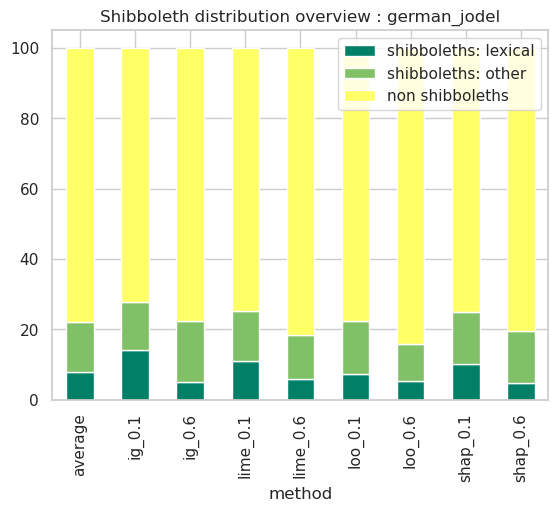

In [61]:
german_jodel_overview.plot(kind='bar', stacked=True, colormap="summer", title="Shibboleth distribution overview : german_jodel").figure.savefig('german_jodel_shib_overview.pdf', bbox_inches='tight')

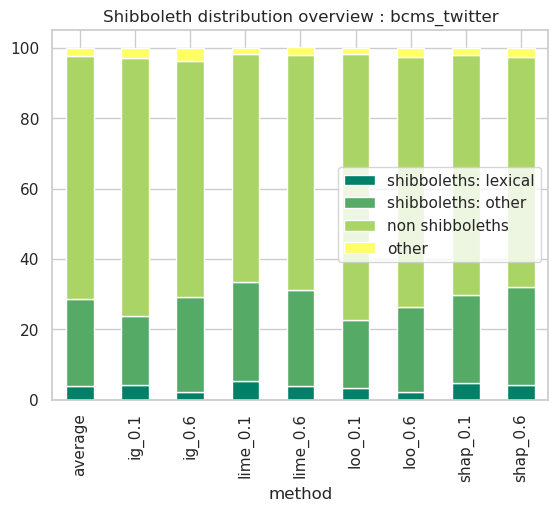

In [62]:
bcms_twitter_overview.plot(kind='bar', stacked=True, colormap="summer", title="Shibboleth distribution overview : bcms_twitter").figure.savefig('bcms_twitter_shib_overview.pdf', bbox_inches='tight')

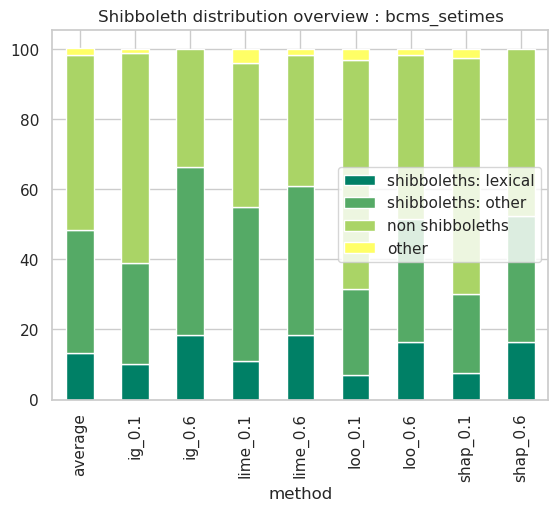

In [63]:
bcms_setimes_overview.plot(kind='bar', colormap="summer", stacked=True, title="Shibboleth distribution overview : bcms_setimes").figure.savefig('bcms_setimes_shib_overview.pdf', bbox_inches='tight')

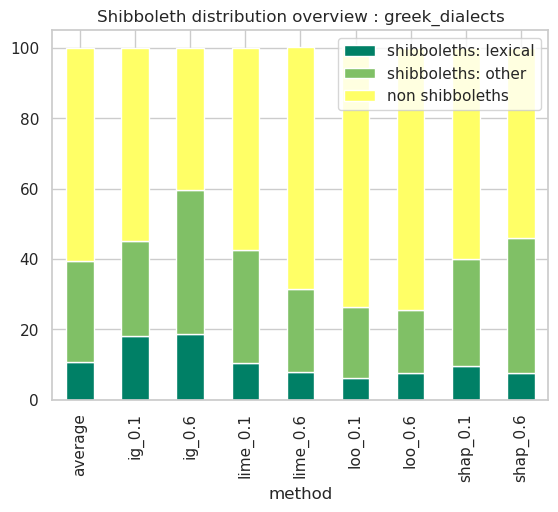

In [64]:
greek_dialects_overview.plot(kind='bar', stacked=True, colormap="summer", title="Shibboleth distribution overview : greek_dialects").figure.savefig('greek_dialects_shib_overview.pdf', bbox_inches='tight')

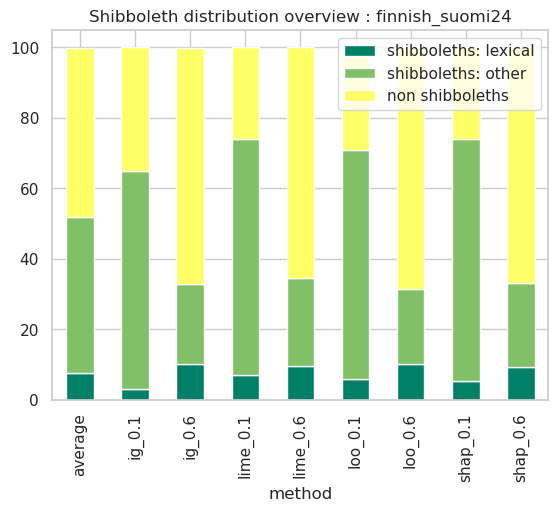

In [65]:
finnish_suomi24_overview.plot(kind='bar', stacked=True, colormap="summer", title="Shibboleth distribution overview : finnish_suomi24").figure.savefig('finnish_suomi24_shib_overview.pdf', bbox_inches='tight')

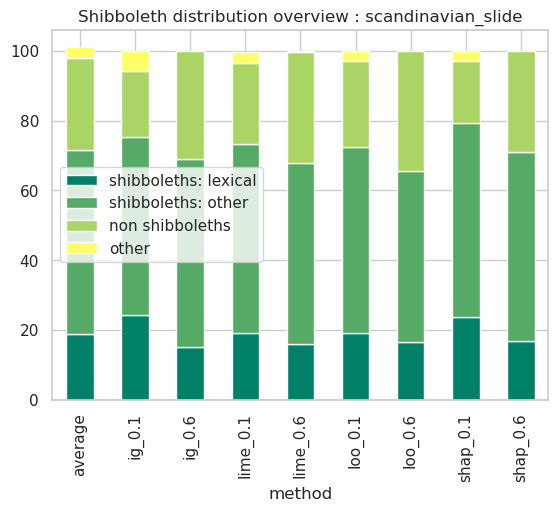

In [66]:
scandinavian_slide_overview.plot(kind='bar', stacked=True, colormap="summer", title="Shibboleth distribution overview : scandinavian_slide").figure.savefig('scandinavian_slide_shib_overview.pdf', bbox_inches='tight')

## Generating csv tables with main results

In [67]:
bcms_setimes_overview.to_csv('bcms_setimes_overview.csv')
bcms_twitter_overview.to_csv('bcms_twitter_overview.csv')
finnish_suomi24_overview.to_csv('finnish_suomi24_overview.csv')
german_jodel_overview.to_csv('german_jodel_overview.csv')
greek_dialects_overview.to_csv('greek_dialects_overview.csv')
scandinavian_slide_overview.to_csv('scandinavian_slide_overview.csv')

# Analysis by method 

In [68]:
bcms_setimes_overview.loc[:, 'dataset'] = 'bcms_setimes'
bcms_setimes_overview

/tmp/ipykernel_5750/114774054.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bcms_setimes_overview.loc[:, 'dataset'] = 'bcms_setimes'


,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
method,,,,,
average,13.2,35.2,49.9,2.2,bcms_setimes
ig_0.1,10.0,29.0,60.0,1.0,bcms_setimes
ig_0.6,18.5,48.0,33.5,NaN,bcms_setimes
lime_0.1,11.0,44.0,41.0,4.0,bcms_setimes
lime_0.6,18.5,42.5,37.5,1.5,bcms_setimes
loo_0.1,7.0,24.5,65.5,3.0,bcms_setimes
loo_0.6,16.5,35.0,47.0,1.5,bcms_setimes
shap_0.1,7.5,22.5,67.5,2.5,bcms_setimes
shap_0.6,16.5,36.0,47.5,NaN,bcms_setimes


In [69]:
bcms_twitter_overview.loc[:, 'dataset'] = 'bcms_twitter'
bcms_twitter_overview

/tmp/ipykernel_5750/3093288178.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bcms_twitter_overview.loc[:, 'dataset'] = 'bcms_twitter'


,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
method,,,,,
average,3.7,24.9,69.0,2.4,bcms_twitter
ig_0.1,4.0,19.8,73.2,3.0,bcms_twitter
ig_0.6,2.2,27.0,67.2,3.5,bcms_twitter
lime_0.1,5.2,28.2,64.8,1.8,bcms_twitter
lime_0.6,3.8,27.3,67.0,2.0,bcms_twitter
loo_0.1,3.2,19.5,75.5,1.8,bcms_twitter
loo_0.6,2.2,24.2,71.0,2.5,bcms_twitter
shap_0.1,4.8,25.0,68.2,2.0,bcms_twitter
shap_0.6,4.0,28.0,65.5,2.5,bcms_twitter


In [70]:
finnish_suomi24_overview.loc[:, 'dataset'] = 'finnish_suomi24'
finnish_suomi24_overview

/tmp/ipykernel_5750/3544459959.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  finnish_suomi24_overview.loc[:, 'dataset'] = 'finnish_suomi24'


,shibboleths: lexical,shibboleths: other,non shibboleths,dataset
method,,,,
average,7.5,44.4,48.0,finnish_suomi24
ig_0.1,3.0,62.0,35.0,finnish_suomi24
ig_0.6,10.2,22.6,67.2,finnish_suomi24
lime_0.1,7.0,67.0,26.0,finnish_suomi24
lime_0.6,9.5,24.9,65.6,finnish_suomi24
loo_0.1,5.7,65.3,29.0,finnish_suomi24
loo_0.6,10.1,21.3,68.6,finnish_suomi24
shap_0.1,5.3,68.7,26.0,finnish_suomi24
shap_0.6,9.2,23.8,67.0,finnish_suomi24


In [71]:
german_jodel_overview.loc[:, 'dataset'] = 'german_jodel'
german_jodel_overview

/tmp/ipykernel_5750/3181395630.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  german_jodel_overview.loc[:, 'dataset'] = 'german_jodel'


,shibboleths: lexical,shibboleths: other,non shibboleths,dataset
method,,,,
average,7.9,14.1,78.0,german_jodel
ig_0.1,14.2,13.5,72.2,german_jodel
ig_0.6,5.0,17.2,77.8,german_jodel
lime_0.1,11.0,14.2,74.8,german_jodel
lime_0.6,5.8,12.5,81.8,german_jodel
loo_0.1,7.2,15.0,77.8,german_jodel
loo_0.6,5.2,10.5,84.2,german_jodel
shap_0.1,10.0,14.8,75.2,german_jodel
shap_0.6,4.8,14.8,80.5,german_jodel


In [72]:
greek_dialects_overview.loc[:, 'dataset'] = 'greek_dialects'
greek_dialects_overview

/tmp/ipykernel_5750/3640696615.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  greek_dialects_overview.loc[:, 'dataset'] = 'greek_dialects'


,shibboleths: lexical,shibboleths: other,non shibboleths,dataset
method,,,,
average,10.7,28.8,60.5,greek_dialects
ig_0.1,18.0,27.0,55.0,greek_dialects
ig_0.6,18.5,41.0,40.5,greek_dialects
lime_0.1,10.5,32.0,57.5,greek_dialects
lime_0.6,7.8,23.5,68.8,greek_dialects
loo_0.1,6.2,20.0,73.8,greek_dialects
loo_0.6,7.5,18.0,74.5,greek_dialects
shap_0.1,9.5,30.5,60.0,greek_dialects
shap_0.6,7.5,38.5,54.0,greek_dialects


In [73]:
scandinavian_slide_overview.loc[:, 'dataset'] = 'scandinavian_slide'
scandinavian_slide_overview

/tmp/ipykernel_5750/265752419.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scandinavian_slide_overview.loc[:, 'dataset'] = 'scandinavian_slide'


,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
method,,,,,
average,18.8,52.9,26.4,2.9,scandinavian_slide
ig_0.1,24.2,51.2,19.0,5.5,scandinavian_slide
ig_0.6,15.2,53.8,31.0,NaN,scandinavian_slide
lime_0.1,19.2,54.2,23.2,3.2,scandinavian_slide
lime_0.6,15.8,52.2,31.8,0.2,scandinavian_slide
loo_0.1,19.2,53.2,24.8,2.8,scandinavian_slide
loo_0.6,16.5,49.0,34.5,NaN,scandinavian_slide
shap_0.1,23.8,55.5,17.8,3.0,scandinavian_slide
shap_0.6,16.8,54.2,29.0,NaN,scandinavian_slide


In [74]:
all_overview = pd.concat([bcms_twitter_overview, bcms_setimes_overview, finnish_suomi24_overview, \
                         german_jodel_overview, greek_dialects_overview, scandinavian_slide_overview], axis=0).reset_index(names=['method'])

all_overview

,method,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
0,average,3.7,24.9,69.0,2.4,bcms_twitter
1,ig_0.1,4.0,19.8,73.2,3.0,bcms_twitter
2,ig_0.6,2.2,27.0,67.2,3.5,bcms_twitter
3,lime_0.1,5.2,28.2,64.8,1.8,bcms_twitter
4,lime_0.6,3.8,27.3,67.0,2.0,bcms_twitter
5,loo_0.1,3.2,19.5,75.5,1.8,bcms_twitter
6,loo_0.6,2.2,24.2,71.0,2.5,bcms_twitter
7,shap_0.1,4.8,25.0,68.2,2.0,bcms_twitter
8,shap_0.6,4.0,28.0,65.5,2.5,bcms_twitter
9,average,13.2,35.2,49.9,2.2,bcms_setimes


In [72]:
all_overview[all_overview['method'] == 'ig_0.1'].set_index('dataset')

,method,shibboleths: lexical,shibboleths: other,non shibboleths,other
dataset,,,,,
bcms_twitter,ig_0.1,4.0,19.8,73.2,3.0
bcms_setimes,ig_0.1,10.0,29.0,60.0,1.0
finnish_twitter,ig_0.1,3.0,62.0,35.0,NaN
german_jodel,ig_0.1,14.2,13.5,72.2,NaN
greek_dialects,ig_0.1,18.0,27.0,55.0,NaN
scandinavian_slide,ig_0.1,24.2,51.2,19.0,5.5


## Generate graphs by method

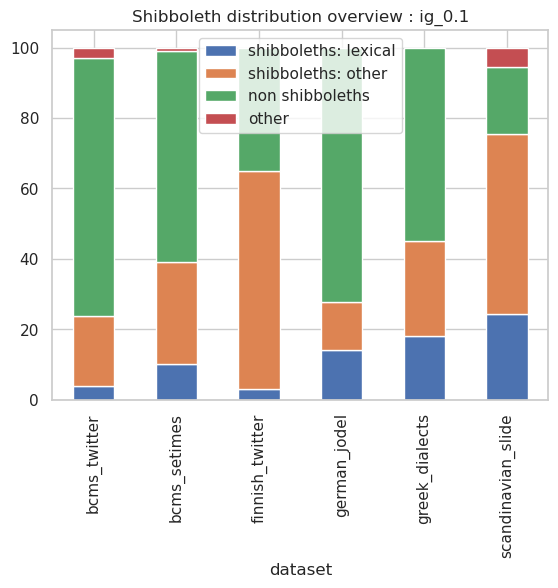

In [89]:
all_overview[all_overview['method'] == 'ig_0.1'].set_index('dataset').plot(kind='bar', stacked=True, title="Shibboleth distribution overview : ig_0.1").figure.savefig('ig_0.1_shib_overview.pdf', bbox_inches='tight')

#all_overview[all_overview['method'] == 'ig_0.1'].set_index('dataset').plot(kind='bar', stacked=True, title="Shibboleth distribution overview : german_jodel").figure.savefig('german_jodel_shib_overview.pdf', bbox_inches='tight')

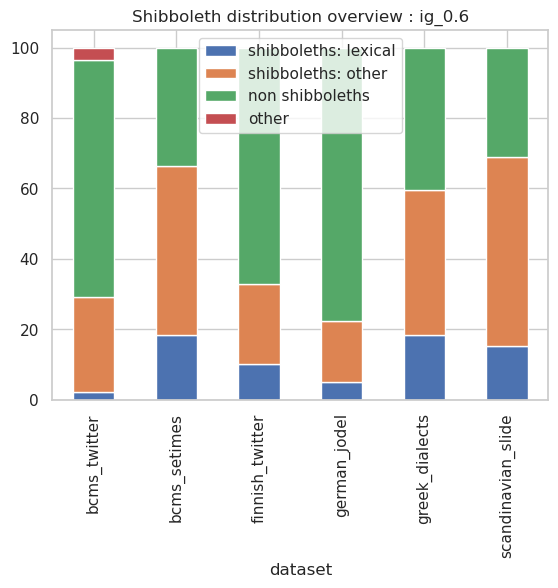

In [90]:
all_overview[all_overview['method'] == 'ig_0.6'].set_index('dataset').plot(kind='bar', stacked=True, title="Shibboleth distribution overview : ig_0.6").figure.savefig('ig_0.6_shib_overview.pdf', bbox_inches='tight')

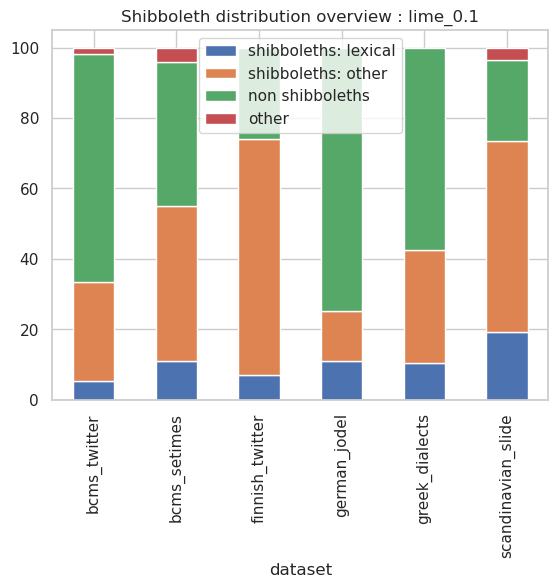

In [91]:
all_overview[all_overview['method'] == 'lime_0.1'].set_index('dataset').plot(kind='bar', stacked=True, title="Shibboleth distribution overview : lime_0.1").figure.savefig('lime_0.1_shib_overview.pdf', bbox_inches='tight')

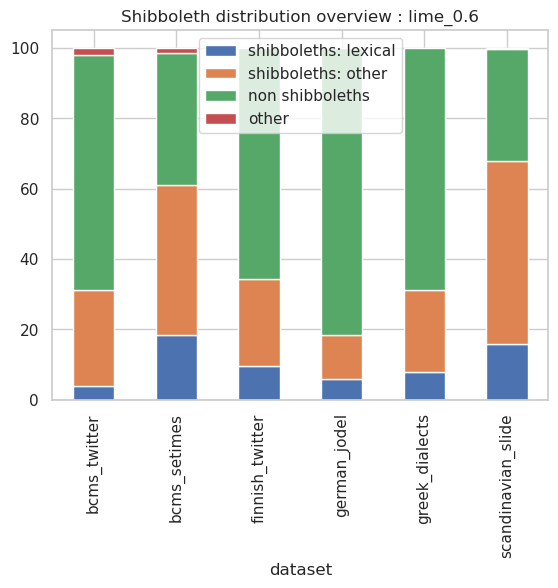

In [92]:
all_overview[all_overview['method'] == 'lime_0.6'].set_index('dataset').plot(kind='bar', stacked=True, title="Shibboleth distribution overview : lime_0.6").figure.savefig('lime_0.6_shib_overview.pdf', bbox_inches='tight')

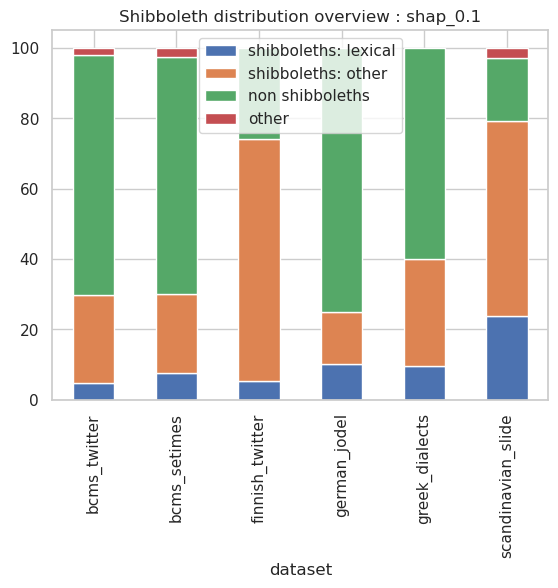

In [93]:
all_overview[all_overview['method'] == 'shap_0.1'].set_index('dataset').plot(kind='bar', stacked=True, title="Shibboleth distribution overview : shap_0.1").figure.savefig('shap_0.1_shib_overview.pdf', bbox_inches='tight')

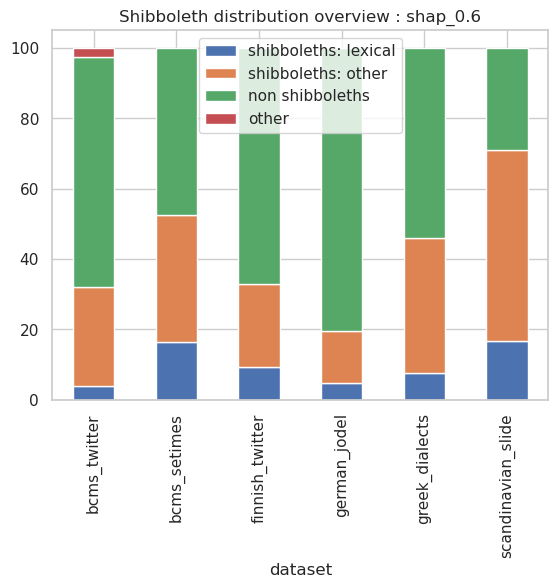

In [94]:
all_overview[all_overview['method'] == 'shap_0.6'].set_index('dataset').plot(kind='bar', stacked=True, title="Shibboleth distribution overview : shap_0.6").figure.savefig('shap_0.6_shib_overview.pdf', bbox_inches='tight')

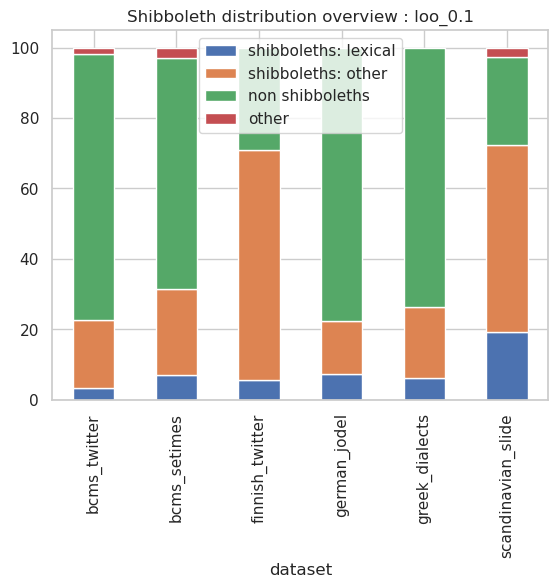

In [95]:
all_overview[all_overview['method'] == 'loo_0.1'].set_index('dataset').plot(kind='bar', stacked=True, title="Shibboleth distribution overview : loo_0.1").figure.savefig('loo_0.1_shib_overview.pdf', bbox_inches='tight')

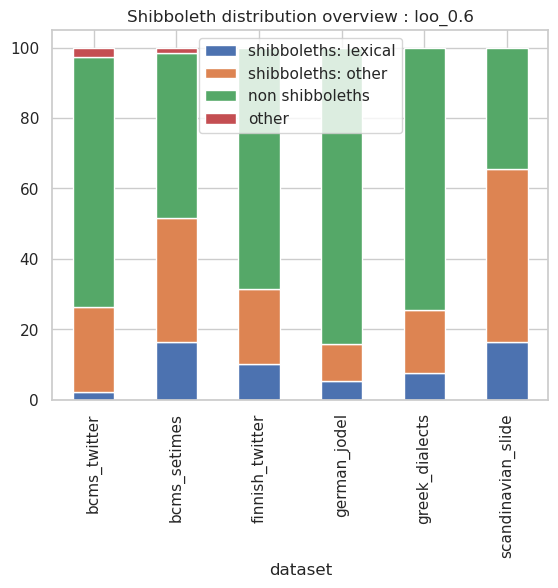

In [96]:
all_overview[all_overview['method'] == 'loo_0.6'].set_index('dataset').plot(kind='bar', stacked=True, title="Shibboleth distribution overview : loo_0.6").figure.savefig('loo_0.6_shib_overview.pdf', bbox_inches='tight')

In [75]:
import matplotlib.cm as cm
import numpy as np

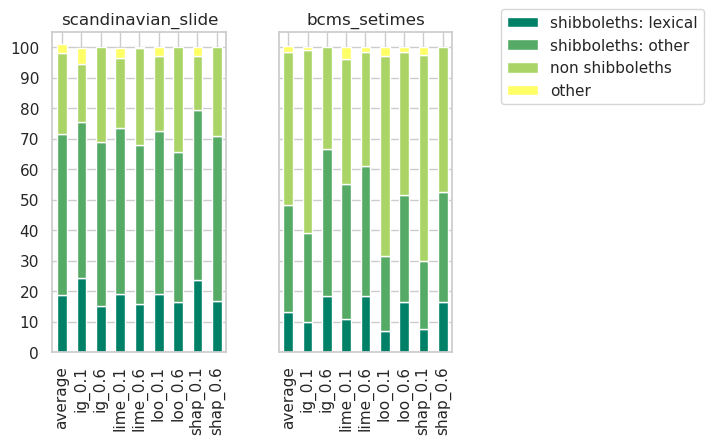

In [97]:
fig, axes = plt.subplots(nrows=1, ncols=2, sharey='row', figsize=(5,4))
all_overview[all_overview['dataset'] == 'scandinavian_slide'].set_index('method').plot(kind='bar', stacked=True, title="scandinavian_slide",  colormap="summer", ax=axes[0], legend=False)
all_overview[all_overview['dataset'] == 'bcms_setimes'].set_index('method').plot(kind='bar', stacked=True, title="bcms_setimes",  colormap="summer", ax=axes[1], legend=False)

axes[0].set_yticks(range(0, 105, 10))
axes[0].set_ylim(0, 105)

axes[0].set_xlabel(None)
axes[1].set_xlabel(None)

ax=axes[1]
handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper center')
plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(1.2, 0.7), bbox_transform=plt.gcf().transFigure)
plt.subplots_adjust(left=0.1, right=0.9, 
                    top=0.9, bottom=0.1, 
                    wspace=0.3, hspace=0.5
                   )
fig.figure.savefig('experiment1-overview.pdf', bbox_inches='tight')


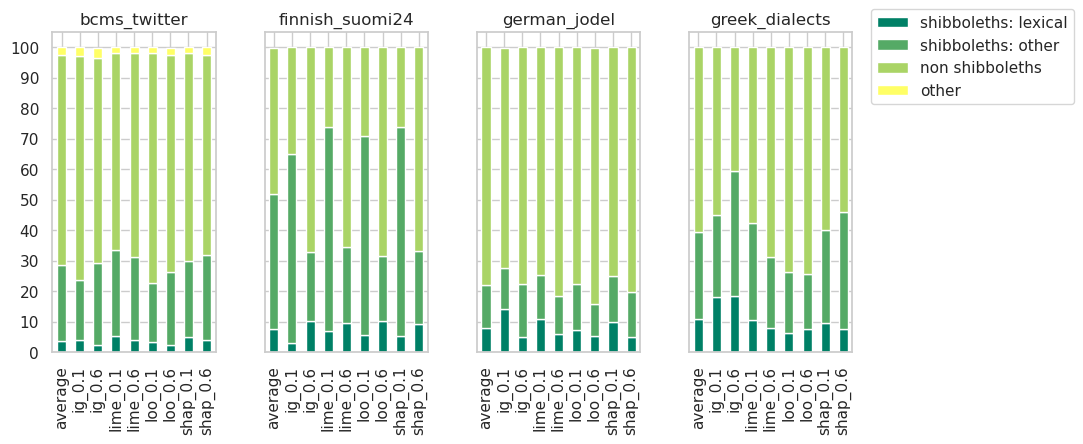

In [101]:
fig, axes = plt.subplots(nrows=1, ncols=4, sharey='row', figsize=(10,4))
all_overview[all_overview['dataset'] == 'bcms_twitter'].set_index('method').plot(kind='bar', stacked=True, title="bcms_twitter",  colormap="summer", ax=axes[0], legend=False)
all_overview[all_overview['dataset'] == 'finnish_suomi24'].set_index('method').plot(kind='bar', stacked=True, title="finnish_suomi24",  colormap="summer", ax=axes[1], legend=False)
all_overview[all_overview['dataset'] == 'german_jodel'].set_index('method').plot(kind='bar', stacked=True, title="german_jodel",  colormap="summer", ax=axes[2], legend=False)
all_overview[all_overview['dataset'] == 'greek_dialects'].set_index('method').plot(kind='bar', stacked=True, title="greek_dialects",  colormap="summer", ax=axes[3], legend=False)                                                                                 
axes[0].set_yticks(range(0, 105, 10))
axes[0].set_ylim(0, 105)

axes[0].set_xlabel(None)
axes[1].set_xlabel(None)
axes[2].set_xlabel(None)
axes[3].set_xlabel(None)

ax=axes[2]
handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper center')
plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(1.02, 0.7), bbox_transform=plt.gcf().transFigure)
plt.subplots_adjust(left=0.1, right=0.9, 
                    top=0.9, bottom=0.1, 
                    wspace=0.3, hspace=0.5
                   )
fig.figure.savefig('experiment2-overview-per_dataset.pdf', bbox_inches='tight')

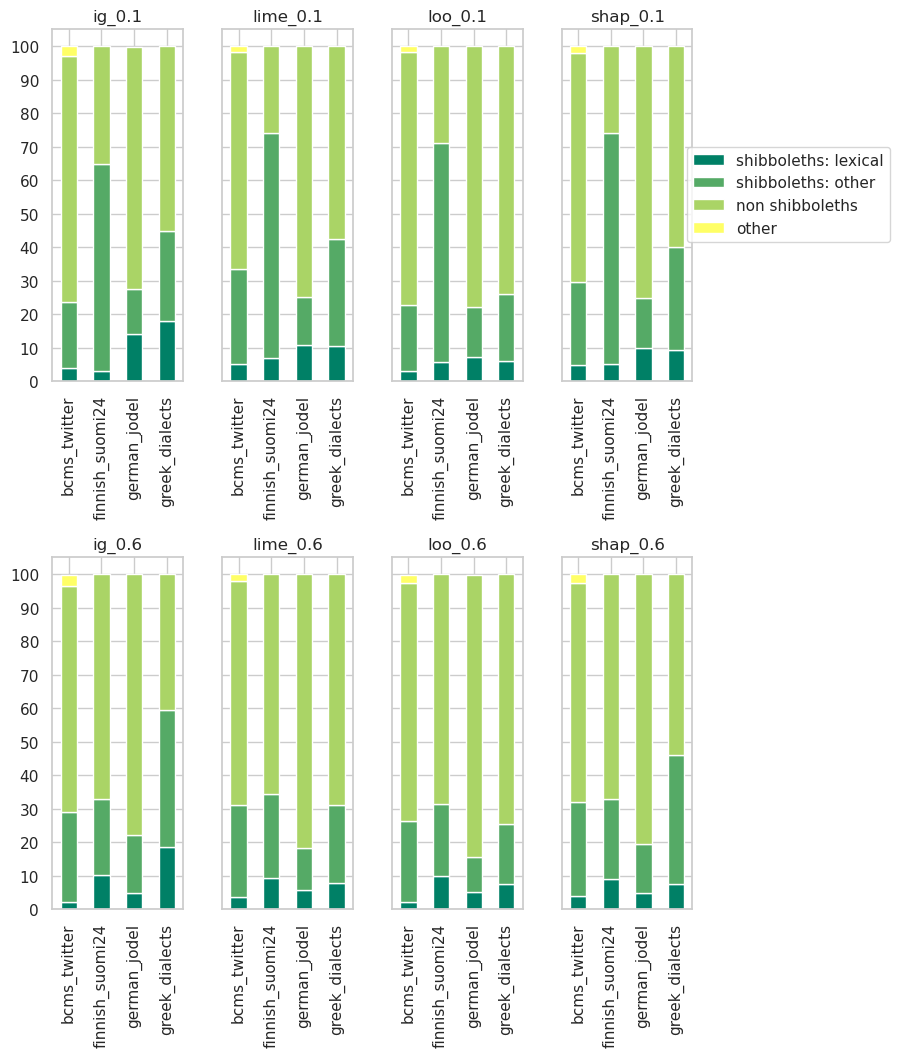

In [116]:
fig, axes = plt.subplots(nrows=2, ncols=4, sharey='row', figsize=(8,11))
subset = ['bcms_twitter', 'finnish_suomi24', 'german_jodel', 'greek_dialects']
all_overview[(all_overview['method'] == 'ig_0.1') & (all_overview['dataset'].isin(subset))].set_index('dataset').plot(kind='bar', stacked=True, title="ig_0.1",  colormap="summer", ax=axes[0,0], legend=False)
all_overview[(all_overview['method'] == 'lime_0.1') & (all_overview['dataset'].isin(subset))].set_index('dataset').plot(kind='bar', stacked=True, title="lime_0.1",  colormap="summer", ax=axes[0,1], legend=False)
all_overview[(all_overview['method'] == 'loo_0.1') & (all_overview['dataset'].isin(subset))].set_index('dataset').plot(kind='bar', stacked=True, title="loo_0.1",  colormap="summer", ax=axes[0,2], legend=False)
all_overview[(all_overview['method'] == 'shap_0.1') & (all_overview['dataset'].isin(subset))].set_index('dataset').plot(kind='bar', stacked=True, title="shap_0.1",  colormap="summer", ax=axes[0,3], legend=False)                                                                                 
all_overview[(all_overview['method'] == 'ig_0.6') & (all_overview['dataset'].isin(subset))].set_index('dataset').plot(kind='bar', stacked=True, title="ig_0.6",  colormap="summer", ax=axes[1,0], legend=False)
all_overview[(all_overview['method'] == 'lime_0.6') & (all_overview['dataset'].isin(subset))].set_index('dataset').plot(kind='bar', stacked=True, title="lime_0.6",  colormap="summer", ax=axes[1,1], legend=False)
all_overview[(all_overview['method'] == 'loo_0.6') & (all_overview['dataset'].isin(subset))].set_index('dataset').plot(kind='bar', stacked=True, title="loo_0.6",  colormap="summer", ax=axes[1,2], legend=False)
all_overview[(all_overview['method'] == 'shap_0.6') & (all_overview['dataset'].isin(subset))].set_index('dataset').plot(kind='bar', stacked=True, title="shap_0.6",  colormap="summer", ax=axes[1,3], legend=False) 

axes[0,1].set_yticks(range(0, 105, 10))
axes[0,1].set_ylim(0, 105)

axes[1,0].set_yticks(range(0, 105, 10))
axes[1,0].set_ylim(0, 105)

axes[0,0].set_xlabel(None)
axes[0,1].set_xlabel(None)
axes[0,2].set_xlabel(None)
axes[0,3].set_xlabel(None)
axes[1,0].set_xlabel(None)
axes[1,1].set_xlabel(None)
axes[1,2].set_xlabel(None)
axes[1,3].set_xlabel(None)

ax=axes[1,3]
handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper center')
plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(1.02, 0.7), bbox_transform=plt.gcf().transFigure)
plt.subplots_adjust(left=0.1, right=0.9, 
                    top=0.9, bottom=0.1, 
                    wspace=0.3, hspace=0.5
                   )
fig.figure.savefig('experiment2-overview-per_method.pdf', bbox_inches='tight')

In [111]:
all_overview[all_overview['method'].isin(['ig_0.1', 'ig_0.6'])]

,method,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
1,ig_0.1,4.0,19.8,73.2,3.0,bcms_twitter
2,ig_0.6,2.2,27.0,67.2,3.5,bcms_twitter
10,ig_0.1,10.0,29.0,60.0,1.0,bcms_setimes
11,ig_0.6,18.5,48.0,33.5,NaN,bcms_setimes
19,ig_0.1,3.0,62.0,35.0,NaN,finnish_suomi24
20,ig_0.6,10.2,22.6,67.2,NaN,finnish_suomi24
28,ig_0.1,14.2,13.5,72.2,NaN,german_jodel
29,ig_0.6,5.0,17.2,77.8,NaN,german_jodel
37,ig_0.1,18.0,27.0,55.0,NaN,greek_dialects
38,ig_0.6,18.5,41.0,40.5,NaN,greek_dialects


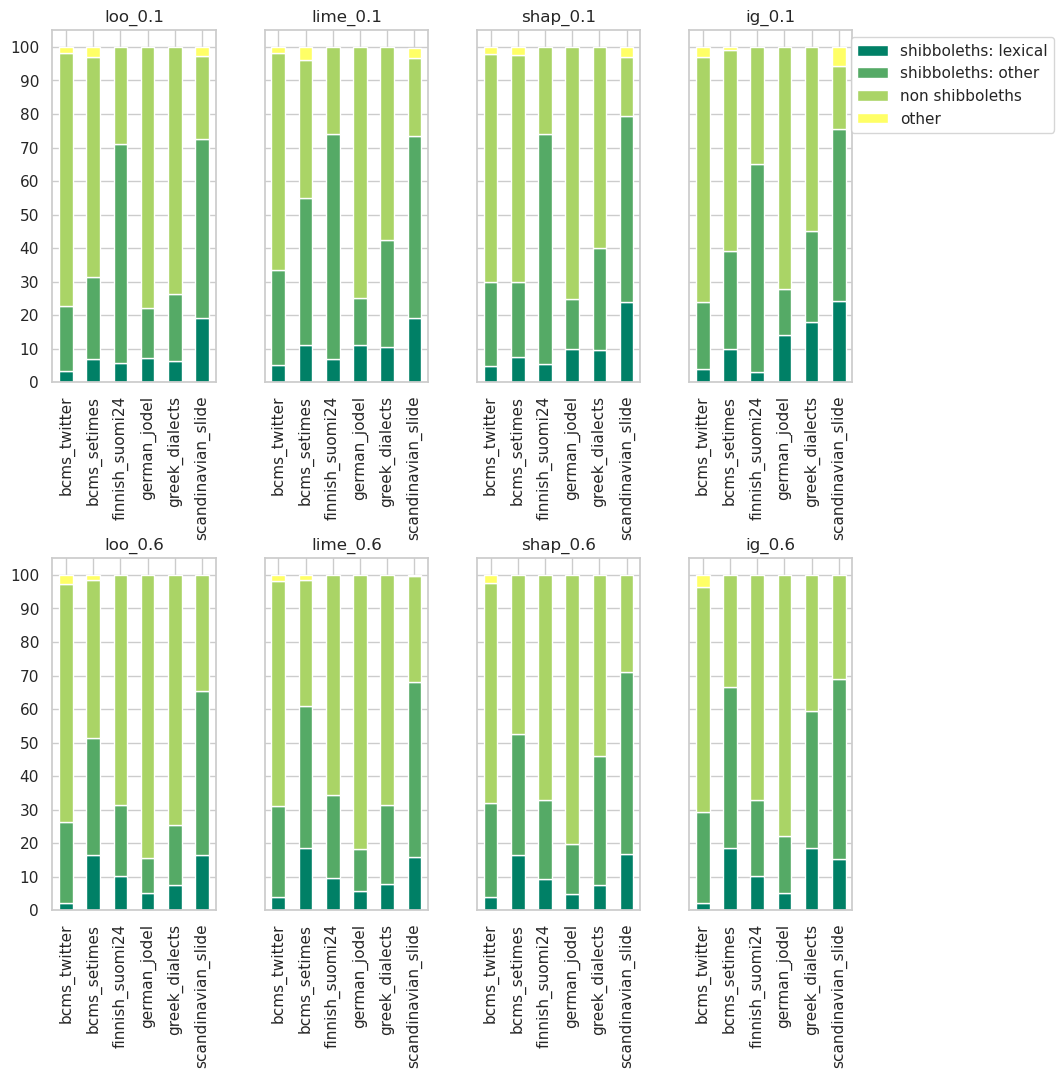

In [254]:
fig, axes = plt.subplots(nrows=2, ncols=4, sharey='row', figsize=(10,11))

all_overview[all_overview['method'] == 'loo_0.1'].set_index('dataset').plot(kind='bar', stacked=True, title="loo_0.1",  colormap="summer", ax=axes[0,0], legend=False)
all_overview[all_overview['method'] == 'loo_0.6'].set_index('dataset').plot(kind='bar', stacked=True, title="loo_0.6",  colormap="summer", ax=axes[1,0], legend=False)
all_overview[all_overview['method'] == 'lime_0.1'].set_index('dataset').plot(kind='bar', stacked=True, title="lime_0.1",  colormap="summer", ax=axes[0,1], legend=False)
all_overview[all_overview['method'] == 'lime_0.6'].set_index('dataset').plot(kind='bar', stacked=True, title="lime_0.6",  colormap="summer", ax=axes[1,1], legend=False)
all_overview[all_overview['method'] == 'shap_0.1'].set_index('dataset').plot(kind='bar', stacked=True, title="shap_0.1",  colormap="summer", ax=axes[0,2], legend=False)
all_overview[all_overview['method'] == 'shap_0.6'].set_index('dataset').plot(kind='bar', stacked=True, title="shap_0.6",  colormap="summer", ax=axes[1,2], legend=False)
all_overview[all_overview['method'] == 'ig_0.1'].set_index('dataset').plot(kind='bar', stacked=True, title="ig_0.1",  colormap="summer", ax=axes[0,3], legend=False)
all_overview[all_overview['method'] == 'ig_0.6'].set_index('dataset').plot(kind='bar', stacked=True, title="ig_0.6",  colormap="summer", ax=axes[1,3], legend=False)

axes[0,0].set_yticks(range(0, 105, 10))
axes[0,0].set_ylim(0, 105)


axes[1,0].set_yticks(range(0, 105, 10))
axes[1,0].set_ylim(0, 105)

axes[0,0].set_xlabel(None)
axes[0,1].set_xlabel(None)
axes[0,2].set_xlabel(None)
axes[0,3].set_xlabel(None)
axes[1,0].set_xlabel(None)
axes[1,1].set_xlabel(None)
axes[1,2].set_xlabel(None)
axes[1,3].set_xlabel(None)

ax=axes[1,3]
handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper center')
plt.legend(handles, labels, loc='lower center', bbox_to_anchor=(1, 0.8), bbox_transform=plt.gcf().transFigure)
plt.subplots_adjust(left=0.1, right=0.9, 
                    top=0.9, bottom=0.1, 
                    wspace=0.3, hspace=0.5)

In [87]:

all_overview

,method,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
0,average,3.7,24.9,69.0,2.4,bcms_twitter
1,ig_0.1,4.0,19.8,73.2,3.0,bcms_twitter
2,ig_0.6,2.2,27.0,67.2,3.5,bcms_twitter
3,lime_0.1,5.2,28.2,64.8,1.8,bcms_twitter
4,lime_0.6,3.8,27.3,67.0,2.0,bcms_twitter
5,loo_0.1,3.2,19.5,75.5,1.8,bcms_twitter
6,loo_0.6,2.2,24.2,71.0,2.5,bcms_twitter
7,shap_0.1,4.8,25.0,68.2,2.0,bcms_twitter
8,shap_0.6,4.0,28.0,65.5,2.5,bcms_twitter
9,average,13.2,35.2,49.9,2.2,bcms_setimes


In [75]:
df_list = [bcms_twitter_overview, bcms_setimes_overview]

In [79]:
def plot_clustered_stacked(dfall, labels=None, title="multiple stacked bar plot",  H="/", **kwargs):
    """Given a list of dataframes, with identical columns and index, create a clustered stacked bar plot. 
labels is a list of the names of the dataframe, used for the legend
title is a string for the title of the plot
H is the hatch used for identification of the different dataframe"""

    n_df = len(dfall)
    n_col = len(dfall[0].columns) 
    n_ind = len(dfall[0].index)
    axe = plt.subplot(111)

    for df in dfall : # for each data frame
        axe = df.plot(kind="bar",
                      linewidth=0,
                      stacked=True,
                      ax=axe,
                      legend=False,
                      grid=False,
                      **kwargs)  # make bar plots

    h,l = axe.get_legend_handles_labels() # get the handles we want to modify
    for i in range(0, n_df * n_col, n_col): # len(h) = n_col * n_df
        for j, pa in enumerate(h[i:i+n_col]):
            for rect in pa.patches: # for each index
                rect.set_x(rect.get_x() + 1 / float(n_df + 1) * i / float(n_col))
                rect.set_hatch(H * int(i / n_col)) #edited part     
                rect.set_width(1 / float(n_df + 1))

    axe.set_xticks((np.arange(0, 2 * n_ind, 2) + 1 / float(n_df + 1)) / 2.)
    axe.set_xticklabels(df.index, rotation = 0)
    axe.set_title(title)

    # Add invisible data to add another legend
    n=[]        
    for i in range(n_df):
        n.append(axe.bar(0, 0, color="gray", hatch=H * i))

    l1 = axe.legend(h[:n_col], l[:n_col], loc=[1.01, 0.5])
    if labels is not None:
        l2 = plt.legend(n, labels, loc=[1.01, 0.1]) 
    axe.add_artist(l1)
    return axe


<Axes: title={'center': 'multiple stacked bar plot'}, xlabel='method'>

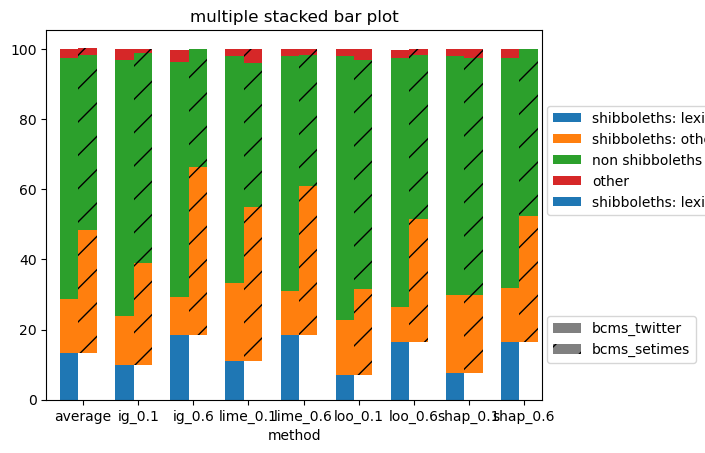

In [80]:
plot_clustered_stacked(df_list, ['bcms_twitter', 'bcms_setimes'])

In [81]:
all_overview

,method,shibboleths: lexical,shibboleths: other,non shibboleths,other,dataset
0,average,3.7,24.9,69.0,2.4,bcms_twitter
1,ig_0.1,4.0,19.8,73.2,3.0,bcms_twitter
2,ig_0.6,2.2,27.0,67.2,3.5,bcms_twitter
3,lime_0.1,5.2,28.2,64.8,1.8,bcms_twitter
4,lime_0.6,3.8,27.3,67.0,2.0,bcms_twitter
5,loo_0.1,3.2,19.5,75.5,1.8,bcms_twitter
6,loo_0.6,2.2,24.2,71.0,2.5,bcms_twitter
7,shap_0.1,4.8,25.0,68.2,2.0,bcms_twitter
8,shap_0.6,4.0,28.0,65.5,2.5,bcms_twitter
9,average,13.2,35.2,49.9,2.2,bcms_setimes


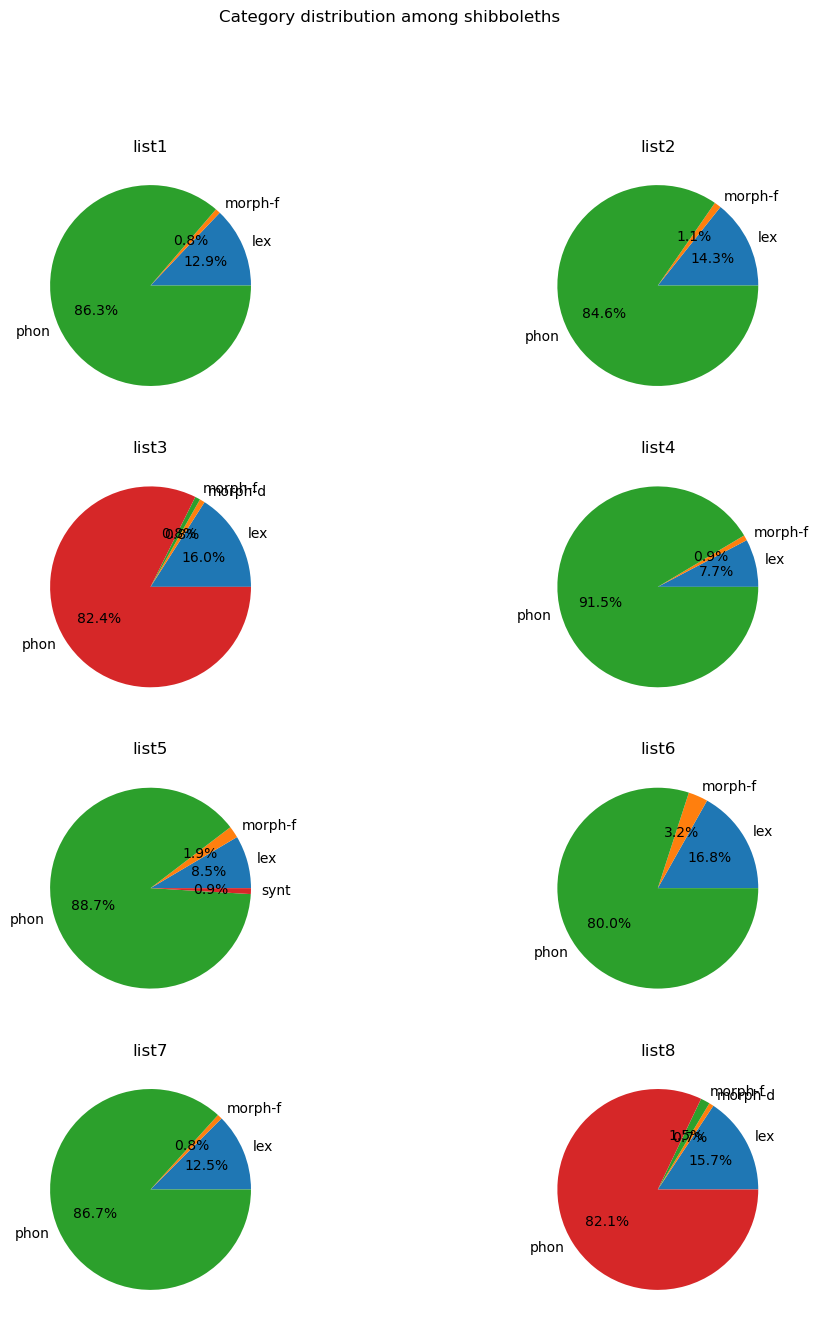

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 15))
fig.suptitle('Category distribution among shibboleths')
axe = axes.ravel()

for i in range(1,9):
    file_id = 'list' + str(i)
    full_df[(full_df['file'] == file_id) & (full_df['shibboleth'] == 'yes')].groupby('feature').size().plot.pie(ax=axe[i-1], title = file_id, autopct='%1.1f%%')
    
fig.savefig('category_distro_shibboleths-twitter.pdf', dpi=300)

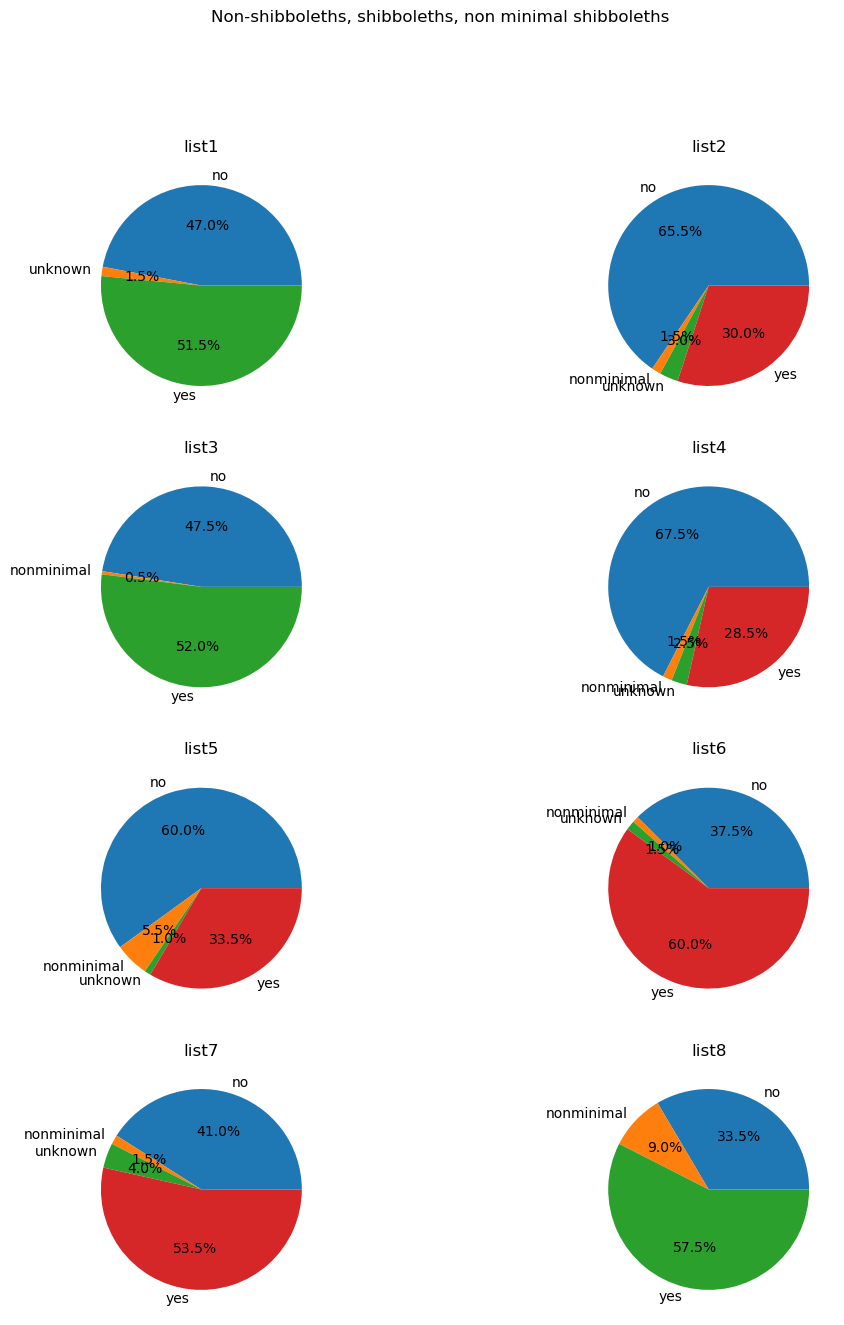

In [26]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 15))
fig.suptitle('Non-shibboleths, shibboleths, non minimal shibboleths')
axe = axes.ravel()

for i in range(1,9):
    file_id = 'list' + str(i)
    full_df[(full_df['file'] == file_id)].groupby('shibboleth').size().plot.pie(ax=axe[i-1], title = file_id, autopct='%1.1f%%')
    
fig.savefig('shibboleths-nonminimal-setimes.pdf', dpi=300)